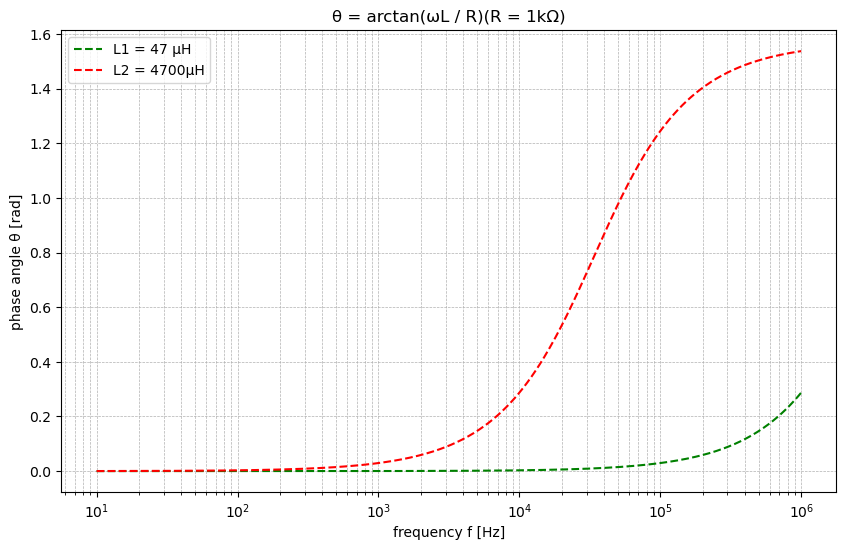

In [19]:
import numpy as np
import matplotlib.pyplot as plt


# 抵抗 R [Ω]
R = 1000

# 周波数 f [Hz]（対数軸用に広範囲で設定）
f = np.logspace(1, 6, 500)  # 10 Hz 〜 1 MHz
omega = 2 * np.pi * f

# インダクタンス
L1 =47*10**-6   # 47μH
L2 = 4700*10**-6  # 4700 µH

# 位相角 θ をラジアンで計算
theta1 = np.arctan((omega * L1 )/ R)
theta2 = np.arctan((omega * L2 )/R)

# グラフ描画
plt.figure(figsize=(10, 6))
plt.plot(f, theta1, color='green', linestyle='--',label='L1 = 47 µH')
plt.plot(f, theta2, color='red', linestyle='--', label='L2 = 4700µH')

plt.xscale('log')
plt.xlabel('frequency f [Hz]')
plt.ylabel('phase angle θ [rad]')
plt.title('θ = arctan(ωL / R)(R = 1kΩ)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# --- データ出力（例：50点ごとに抜粋） ---
sample_freqs = f[::50]
sample_theta1 = theta1[::50]
sample_theta2 = theta2[::50]

# 表示


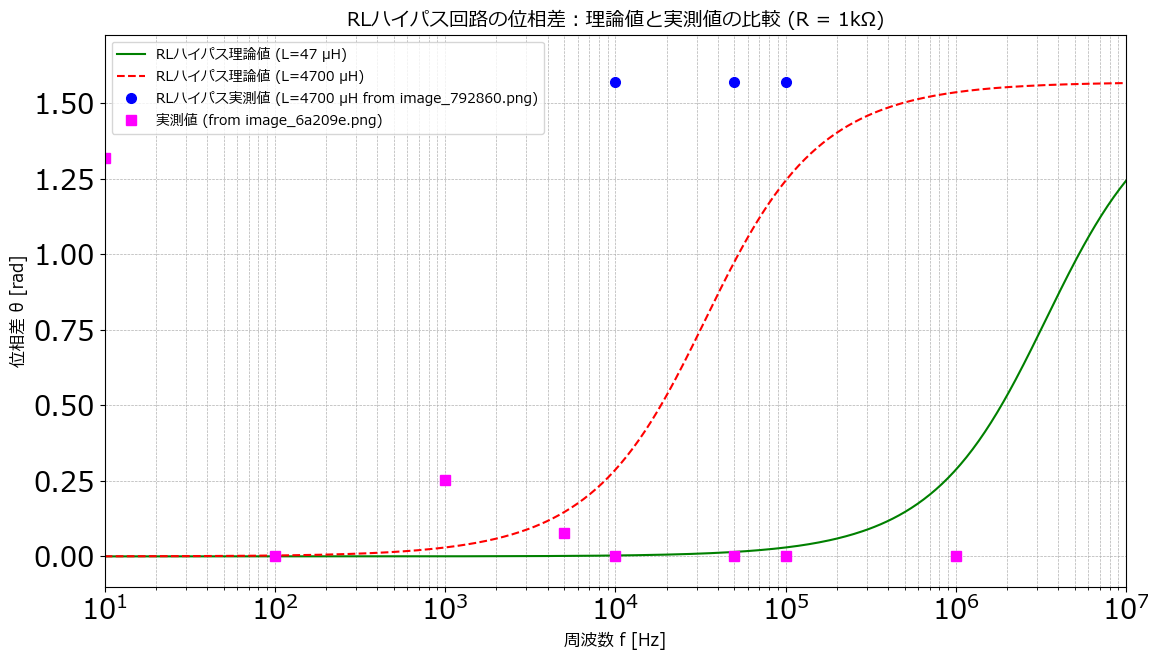

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 日本語フォントの設定 ---
font_name = 'Meiryo' # 例: Windowsの場合

try:
    prop = fm.FontProperties(family=font_name)
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止
except Exception as e:
    print(f"Warning: Font setting failed. Error: {e}")
    print("Falling back to default font. Japanese characters might not display correctly.")
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False

# 抵抗 R [Ω]
R = 1000

# 周波数 f [Hz]（対数軸用に広範囲で設定）
f_theory = np.logspace(1, 7, 500)  # 10 Hz 〜 10 MHz
omega_theory = 2 * np.pi * f_theory

# インダクタンス
L1 = 47 * 10**-6    # 47 µH
L2 = 4700 * 10**-6  # 4700 µH (4.7 mH)

# RLハイパス回路の位相角 θ をラジアンで計算: θ = arctan(ωL / R)
theta1_theory = np.arctan((omega_theory * L1) / R)
theta2_theory = np.arctan((omega_theory * L2) / R)

# --- 実測値データ 1 (image_792860.pngより - L=4700µHに対応) ---
observed_freq_phase_L2 = np.array([10000, 50000, 100000])
observed_phase_L2 = np.array([1.570796, 1.570796, 1.570796])

# --- 新しい実測値データ 2 (image_6a209e.pngより) ---
# このデータはRCローパスフィルターの位相差に似ていますが、指示に従ってプロットします。
observed_freq_rc_lowpass_phase = np.array([10, 100, 1000, 5000, 10000, 50000, 100000, 1000000])
observed_phase_rc_lowpass = np.array([1.319469, 0.001131, 0.251327, 0.07854, 0, 0, 0, 0])

# --- グラフ描画 ---
plt.figure(figsize=(12, 7))

# 理論値のプロット
plt.plot(f_theory, theta1_theory, color='green', linestyle='-', linewidth=1.5, label='RLハイパス理論値 (L=47 µH)')
plt.plot(f_theory, theta2_theory, color='red', linestyle='--', linewidth=1.5, label='RLハイパス理論値 (L=4700 µH)')

# 実測値のプロット 1 (image_792860.pngのデータ - L=4700µHに対応)
plt.plot(observed_freq_phase_L2, observed_phase_L2, 'o', color='blue', markersize=7, label='RLハイパス実測値 (L=4700 µH from image_792860.png)')

# 新しい実測値のプロット 2 (image_6a209e.pngのデータ)
# データ点が非常に異なる特性を示すため、重ねると視認性が悪くなる可能性があります。
# マーカーを's'（四角）、色をマゼンタに設定
plt.plot(observed_freq_rc_lowpass_phase, observed_phase_rc_lowpass, 's', color='magenta', markersize=7, label='実測値 (from image_6a209e.png)')


plt.xscale('log')
plt.xlabel('周波数 f [Hz]', fontsize=12)
plt.ylabel('位相差 θ [rad]', fontsize=12)
plt.title('RLハイパス回路の位相差：理論値と実測値の比較 (R = 1kΩ)', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=10)
# Y軸の範囲をデータ全体が入るように調整 (RCローパスのデータは非常に低い値を含むため)
plt.ylim(min(0, np.min(observed_phase_rc_lowpass) - 0.1), max(np.pi / 2 * 1.1, np.max(observed_phase_rc_lowpass) + 0.1))
plt.xlim(10, 10**7) # 周波数範囲を調整

plt.tight_layout()
plt.show()

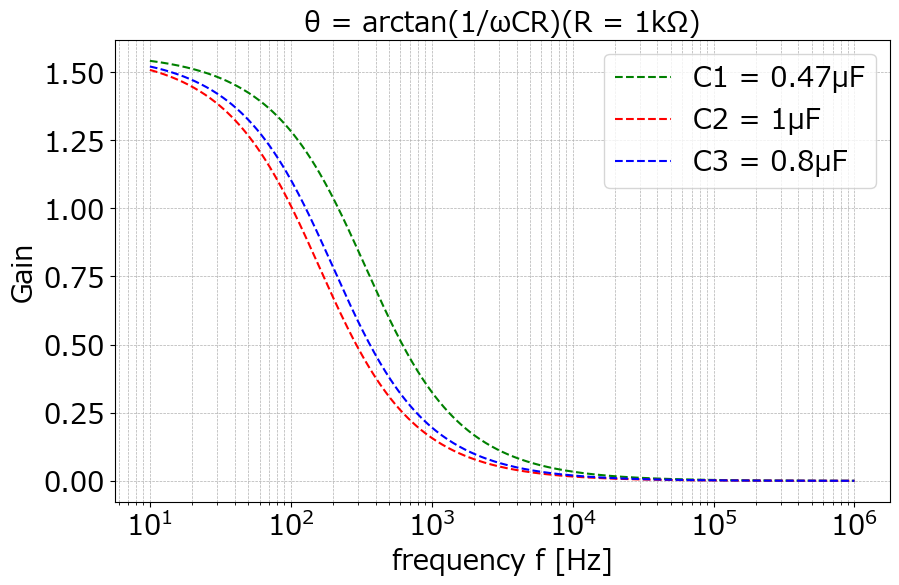

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 抵抗 R [Ω]
R = 1000

# 周波数 f [Hz]（対数軸用に広範囲で設定）
f = np.logspace(1, 6, 500)  # 10 Hz 〜 1 MHz
omega = 2 * np.pi * f

# インダクタンス
C1 =0.47*10**-6   # 0.47μF
C2 =1.0*10**-6  # 1 µF
C3=0.8*10**-6  #0.8 µF

# 位相角 θ をラジアンで計算
theta1 = np.arctan(1/(omega * C1* R))
theta2 = np.arctan(1/(omega * C2 *R))
theta3 = np.arctan(1/(omega * C3 *R))
                   
# グラフ描画
plt.figure(figsize=(10, 6))
plt.plot(f, theta1, color='green', linestyle='--',label='C1 = 0.47µF')
plt.plot(f, theta2, color='red', linestyle='--', label='C2 = 1µF')
plt.plot(f, theta3, color='blue', linestyle='--', label='C3 = 0.8µF')

plt.xscale('log')
plt.xlabel('frequency f [Hz]')
plt.ylabel('Gain')
plt.title('θ = arctan(1/ωCR)(R = 1kΩ)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


In [14]:
import numpy as np

# 抵抗 R [Ω]
R = 1000

# インダクタンス
L1 = 47 * 10**-6    # 47 µH
L2 = 4700 * 10**-6  # 4700 µH (4.7 mH)

# 計算したい周波数
f_calc_1 = 50000  # Hz
f_calc_2 = 100000 # Hz

# 各周波数での角周波数
omega_calc_1 = 2 * np.pi * f_calc_1
omega_calc_2 = 2 * np.pi * f_calc_2

# RLハイパス回路の位相角 θ をラジアンで計算: θ = arctan(ωL / R)
# この式は、インダクタンスにかかる電圧が入力電圧に対してどれだけ位相が進んでいるかを示します。
theta_L1_at_50000Hz_rad = np.arctan((omega_calc_1 * L1) / R)
theta_L1_at_100000Hz_rad = np.arctan((omega_calc_2 * L1) / R)

theta_L2_at_50000Hz_rad = np.arctan((omega_calc_1 * L2) / R)
theta_L2_at_100000Hz_rad = np.arctan((omega_calc_2 * L2) / R)

# ラジアンを度に変換（参考情報として）
theta_L1_at_50000Hz_deg = np.degrees(theta_L1_at_50000Hz_rad)
theta_L1_at_100000Hz_deg = np.degrees(theta_L1_at_100000Hz_rad)

theta_L2_at_50000Hz_deg = np.degrees(theta_L2_at_50000Hz_rad)
theta_L2_at_100000Hz_deg = np.degrees(theta_L2_at_100000Hz_rad)

print(f"--- 50000 Hz での位相角 ---")
print(f"L=47 µH:   {theta_L1_at_50000Hz_rad:.3f} rad ({theta_L1_at_50000Hz_deg:.1f} deg)")
print(f"L=4700 µH: {theta_L2_at_50000Hz_rad:.3f} rad ({theta_L2_at_50000Hz_deg:.1f} deg)")
print(f"\n--- 100000 Hz での位相角 ---")
print(f"L=47 µH:   {theta_L1_at_100000Hz_rad:.3f} rad ({theta_L1_at_100000Hz_deg:.1f} deg)")
print(f"L=4700 µH: {theta_L2_at_100000Hz_rad:.3f} rad ({theta_L2_at_100000Hz_deg:.1f} deg)")

--- 50000 Hz での位相角 ---
L=47 µH:   0.015 rad (0.8 deg)
L=4700 µH: 0.975 rad (55.9 deg)

--- 100000 Hz での位相角 ---
L=47 µH:   0.030 rad (1.7 deg)
L=4700 µH: 1.244 rad (71.3 deg)


In [15]:
import numpy as np

import matplotlib.pyplot as plt

import matplotlib.font_manager as fm



# --- 日本語フォントの設定 ---

font_name = 'Meiryo' # 例: Windowsの場合



# プロット設定

plt.rcParams['font.size'] = 20

plt.rcParams['axes.titlesize'] = 20

plt.rcParams['axes.labelsize'] = 20

plt.rcParams['legend.fontsize'] = 20

plt.rcParams['xtick.labelsize'] = 20

plt.rcParams['ytick.labelsize'] = 20





try:

    prop = fm.FontProperties(family=font_name)

    plt.rcParams['font.family'] = font_name

    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止

except Exception as e:

    print(f"Warning: Font setting failed. Error: {e}")

    print("Falling back to default font. Japanese characters might not display correctly.")

    plt.rcParams['font.family'] = 'DejaVu Sans'

    plt.rcParams['axes.unicode_minus'] = False



# 抵抗 R [Ω]

R = 1000



# 周波数 f [Hz]（対数軸用に広範囲で設定）

f_theory = np.logspace(1, 7, 500)  # 10 Hz 〜 10 MHz

omega_theory = 2 * np.pi * f_theory



# インダクタンス

L1 = 47 * 10**-6    # 47 µH

L2 = 4700 * 10**-6  # 4700 µH (4.7 mH)



# RLハイパス回路の位相角 θ をラジアンで計算: θ = arctan(ωL / R)

theta1_theory = np.arctan((omega_theory * L1) / R)

theta2_theory = np.arctan((omega_theory * L2) / R)



# --- 提供された実測値データ ---

# 実測データ1（4700μH ）

data1 = np.array([

    [1000, 0.002],

    [10000, 0.25],

    [100000, 1],

])



# 実測データ2（47μH ）

data2 = np.array([

    [1000, 0],

    [10000, 0.0323],

    [100000, 0.1],

    [1000000, 0.3]

])



# データから周波数と位相差を抽出

observed_freq_L2 = data1[:, 0]

observed_phase_L2 = data1[:, 1]



observed_freq_L1 = data2[:, 0]

observed_phase_L1 = data2[:, 1]



# --- グラフ描画 ---

plt.figure(figsize=(12, 7))



# 理論値のプロット

plt.plot(f_theory, theta1_theory, color='green', linestyle='--', linewidth=1.5, label='RL理論値 (L=47 µH)')

plt.plot(f_theory, theta2_theory, color='blue', linestyle='--', linewidth=1.5, label='RL理論値 (L=4700 µH)')



# 実測値のプロット (データ1 - L=4700µHに対応)

plt.plot(observed_freq_L2, observed_phase_L2, 'o', color='blue', markersize=7, label='実測値 (L=4700 µH)')



# 実測値のプロット (データ2 - L=47µHに対応)

plt.plot(observed_freq_L1, observed_phase_L1, 'o', color='green', markersize=7, label='実測値 (L=47 µH)')



plt.xscale('log')

plt.xlabel('振動数 f [Hz]', fontsize=20)

plt.ylabel('位相差 θ [rad]', fontsize=20)

plt.title('RL回路の位相差：理論値と実測値の比較 (R = 1kΩ)', fontsize=20)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.legend(fontsize=20)

# 位相差は0からpi/2ラジアン（約1.57ラジアン）なので、少し余裕を持たせる

plt.ylim(-0.1, np.pi / 2 * 1.1)

plt.xlim(10, 10**7) # 周波数範囲を調整



plt.tight_layout()

plt.show()

SyntaxError: invalid non-printable character U+00A0 (4101170231.py, line 35)

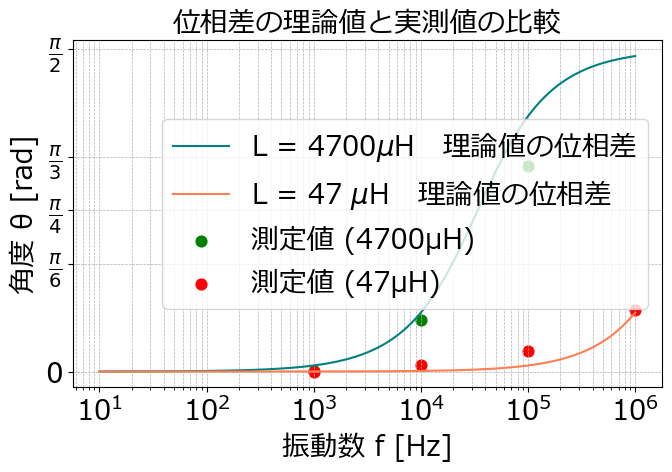

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 抵抗 R [Ω]
R = 1000

# 周波数 f [Hz]
f = np.logspace(1, 6, 500)
omega = 2 * np.pi * f

# インダクタンス
L1 = 4.7e-3   # 4.7 mH
L2 = 47e-6    # 47 µH

# 位相角 θ をラジアンで計算
theta1 = np.arctan(omega * L1 / R)
theta2 = np.arctan(omega * L2 / R)

# プロット設定
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

# --- グラフ描画 ---
plt.figure(figsize=(7, 5))
plt.plot(f, theta1, color='teal', label=r'L = 4700$\mu$H　理論値の位相差')
plt.plot(f, theta2, color='coral', label=r'L = 47 $\mu$H　理論値の位相差')

# 実測データ1（4700μH ）
data1 = np.array([
    [1000, 0.002],
    [10000, 0.25],
    [100000, 1]
])
  

# 実測データ2（47μH ）
data2 = np.array([
    [1000, 0],
    [10000, 0.0323],
    [100000, 0.1],
    [1000000, 0.3]
])

# 有効なデータのみ抽出
valid_mask1 = ~np.isnan(data1[:,1])
f_data1 = data1[valid_mask1, 0]
theta_data1 = data1[valid_mask1, 1]

valid_mask2 = ~np.isnan(data2[:,1])
f_data2 = data2[valid_mask2, 0]
theta_data2 = data2[valid_mask2, 1]

# 散布図としてプロット
plt.scatter(f_data1, theta_data1, color='green', marker='o', s=60, label='測定値 (4700μH)')
plt.scatter(f_data2, theta_data2, color='red', marker='o', s=60, label='測定値 (47μH)')

# 軸設定
plt.xscale('log')
plt.xlabel('振動数 f [Hz]')
plt.ylabel('角度 θ [rad]')
plt.title('位相差の理論値と実測値の比較')

# π単位で目盛り
pi = np.pi
plt.yticks(
    [0, pi/6, pi/4, pi/3, pi/2],
    [r'$0$', r'$\frac{\pi}{6}$', r'$\frac{\pi}{4}$',
     r'$\frac{\pi}{3}$', r'$\frac{\pi}{2}$']
)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

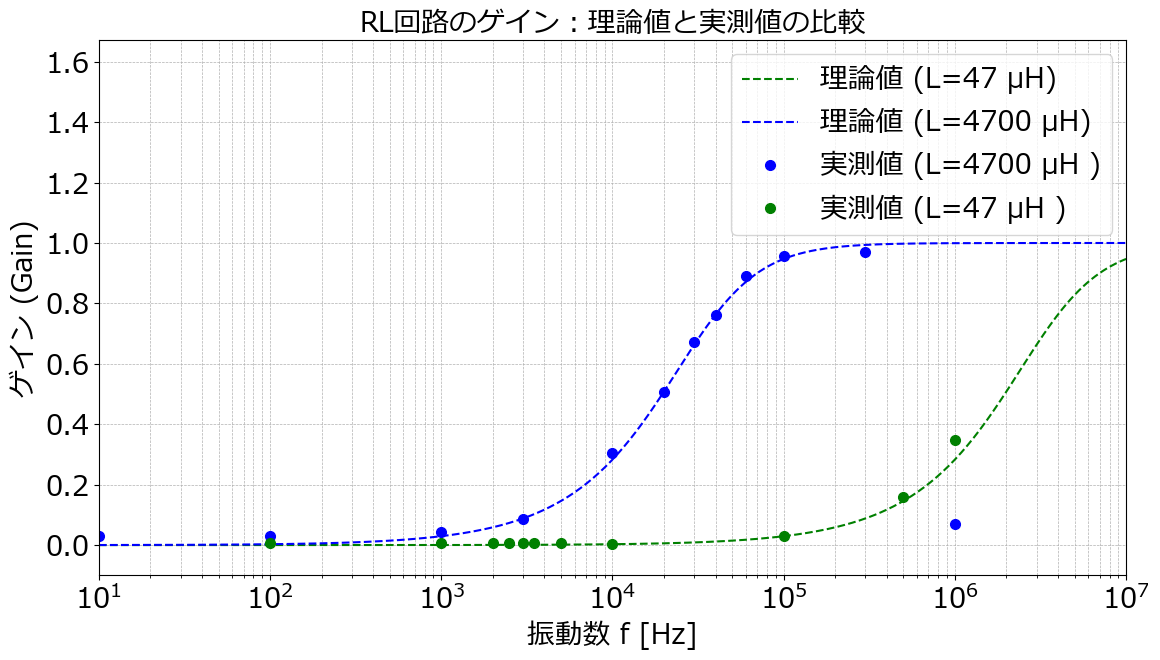

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 日本語フォントの設定 ---
font_name = 'Meiryo' # 例: Windowsの場合
# プロット設定
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

try:
    prop = fm.FontProperties(family=font_name)
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止
except Exception as e:
    print(f"Warning: Font setting failed. Error: {e}")
    print("Falling back to default font. Japanese characters might not display correctly.")
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False

# 抵抗 R [Ω]
R = 1000

# 周波数 f [Hz]（対数軸用に広範囲で設定）
f_theory = np.logspace(1, 7, 500)  # 10 Hz 〜 10 MHz
omega_theory = 2 * np.pi * f_theory

# インダクタンス
L1 = 47 * 10**-6    # 47 µH
L2 = 4700 * 10**-6  # 4700 µH (4.7 mH)

# RLハイパス回路のゲインを計算: Vout/Vin = (omega*L) / sqrt(R^2 + (omega*L)^2)
Gain_L1_theory = (omega_theory * L1) / np.sqrt((R**2) + ((omega_theory * L1)**2))
Gain_L2_theory = (omega_theory * L2) / np.sqrt((R**2) + ((omega_theory * L2)**2))

# --- 実測値データ 1 (image_76f124.pngより) ---
# RLハイパス回路、L=4700µHに対応
observed_freq_RL_HP_L2 = np.array([10, 100, 1000, 3000, 10000, 20000, 30000, 40000, 60000, 100000, 300000, 1000000])
observed_gain_RL_HP_L2 = np.array([0.031414, 0.030435, 0.042781, 0.087701, 0.306122, 0.507389, 0.672727, 0.761702, 0.891892, 0.955479, 0.971731, 0.069898])

# --- 新しい実測値データ 2 (image_775edd.pngより) ---
# RLハイパス回路、L=47µHに対応
observed_freq_RL_HP_L1 = np.array([100, 1000, 2000, 2500, 3000, 3500, 5000, 10000, 100000, 500000, 1000000])
observed_gain_RL_HP_L1 = np.array([0.006522, 0.006522, 0.006417, 0.006417, 0.006417, 0.006417, 0.006417, 0.003102, 0.029519, 0.159162, 0.346939])

# --- グラフ描画 ---
plt.figure(figsize=(12, 7))

# 理論値のプロット
plt.plot(f_theory, Gain_L1_theory, color='green', linestyle='--', linewidth=1.5, label='理論値 (L=47 µH)')
plt.plot(f_theory, Gain_L2_theory, color='blue', linestyle='--', linewidth=1.5, label='理論値 (L=4700 µH)')

# 実測値のプロット 1 (image_76f124.pngのデータ - L=4700µHに対応)
plt.plot(observed_freq_RL_HP_L2, observed_gain_RL_HP_L2, 'o', color='blue', markersize=7, label='実測値 (L=4700 µH )')

# 新しい実測値のプロット 2 (image_775edd.pngのデータ - L=47µHに対応)
plt.plot(observed_freq_RL_HP_L1, observed_gain_RL_HP_L1, 'o', color='green', markersize=7, label='実測値 (L=47 µH )')

plt.xscale('log')
plt.xlabel('振動数 f [Hz]', fontsize=20)
plt.ylabel('ゲイン (Gain)', fontsize=20)
plt.title('RL回路のゲイン：理論値と実測値の比較', fontsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=20)
plt.ylim(0, 1.1) # ゲインの範囲を0から1.1に固定
plt.xlim(10, 10**7) # 周波数範囲を実測値に合わせて調整
# Y軸の範囲をマイナスまで広げてゼロ値を見やすくする
plt.ylim(-0.1, np.pi / 2 + 0.1) # 下限を-0.1ラジアンに設定

plt.tight_layout()
plt.show()

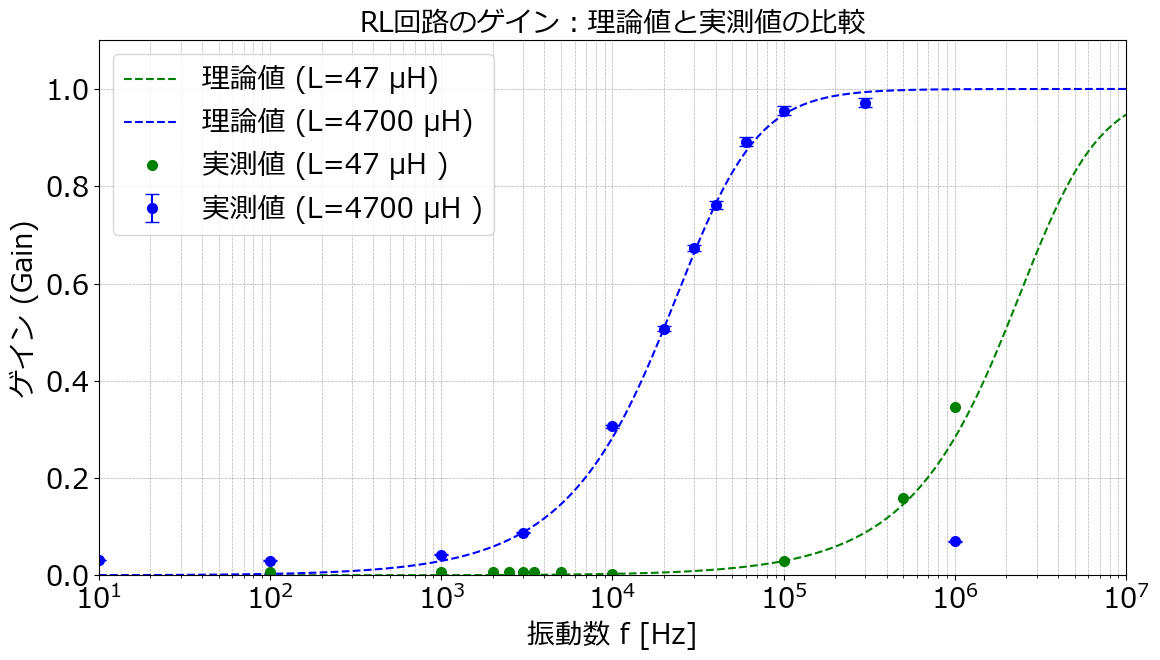

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 日本語フォントの設定 ---
font_name = 'Meiryo' # 例: Windowsの場合
# プロット設定
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

try:
    prop = fm.FontProperties(family=font_name)
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止
except Exception as e:
    print(f"Warning: Font setting failed. Error: {e}")
    print("Falling back to default font. Japanese characters might not display correctly.")
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False

# 抵抗 R [Ω]
R = 1000

# 周波数 f [Hz]（対数軸用に広範囲で設定）
f_theory = np.logspace(1, 7, 500)  # 10 Hz 〜 10 MHz
omega_theory = 2 * np.pi * f_theory

# インダクタンス
L1 = 47 * 10**-6    # 47 µH
L2 = 4700 * 10**-6  # 4700 µH (4.7 mH)

# RLハイパス回路のゲインを計算: Vout/Vin = (omega*L) / sqrt(R^2 + (omega*L)^2)
Gain_L1_theory = (omega_theory * L1) / np.sqrt((R**2) + ((omega_theory * L1)**2))
Gain_L2_theory = (omega_theory * L2) / np.sqrt((R**2) + ((omega_theory * L2)**2))

# --- 実測値データ 1 (L=4700µHに対応) と誤差 ---
observed_freq_RL_HP_L2 = np.array([10, 100, 1000, 3000, 10000, 20000, 30000, 40000, 60000, 100000, 300000, 1000000])
observed_gain_RL_HP_L2 = np.array([0.031414, 0.030435, 0.042781, 0.087701, 0.306122, 0.507389, 0.672727, 0.761702, 0.891892, 0.955479, 0.971731, 0.069898])
# image_f2e91e.png から読み取った誤差データ
error_gain_RL_HP_L2 = np.array([0.0003, 0.0003, 0.0004, 0.0009, 0.0031, 0.0051, 0.0067, 0.0076, 0.0089, 0.0096, 0.0097, 0.0007])


# --- 新しい実測値データ 2 (L=47µHに対応) ---
observed_freq_RL_HP_L1 = np.array([100, 1000, 2000, 2500, 3000, 3500, 5000, 10000, 100000, 500000, 1000000])
observed_gain_RL_HP_L1 = np.array([0.006522, 0.006522, 0.006417, 0.006417, 0.006417, 0.006417, 0.006417, 0.003102, 0.029519, 0.159162, 0.346939])

# --- グラフ描画 ---
plt.figure(figsize=(12, 7))

# 理論値のプロット
plt.plot(f_theory, Gain_L1_theory, color='green', linestyle='--', linewidth=1.5, label='理論値 (L=47 µH)')
plt.plot(f_theory, Gain_L2_theory, color='blue', linestyle='--', linewidth=1.5, label='理論値 (L=4700 µH)')

# 実測値のプロット 1 (L=4700µHに対応) に誤差棒を追加
plt.errorbar(observed_freq_RL_HP_L2, observed_gain_RL_HP_L2, yerr=error_gain_RL_HP_L2,
             fmt='o', color='blue', markersize=7, capsize=5, label='実測値 (L=4700 µH )')

# 新しい実測値のプロット 2 (L=47µHに対応)
plt.plot(observed_freq_RL_HP_L1, observed_gain_RL_HP_L1, 'o', color='green', markersize=7, label='実測値 (L=47 µH )')

plt.xscale('log')
plt.xlabel('振動数 f [Hz]', fontsize=20)
plt.ylabel('ゲイン (Gain)', fontsize=20)
plt.title('RL回路のゲイン：理論値と実測値の比較', fontsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=20)
plt.ylim(0, 1.1) # ゲインの範囲を0から1.1に固定
plt.xlim(10, 10**7) # 周波数範囲を実測値に合わせて調整

plt.tight_layout()
plt.show()


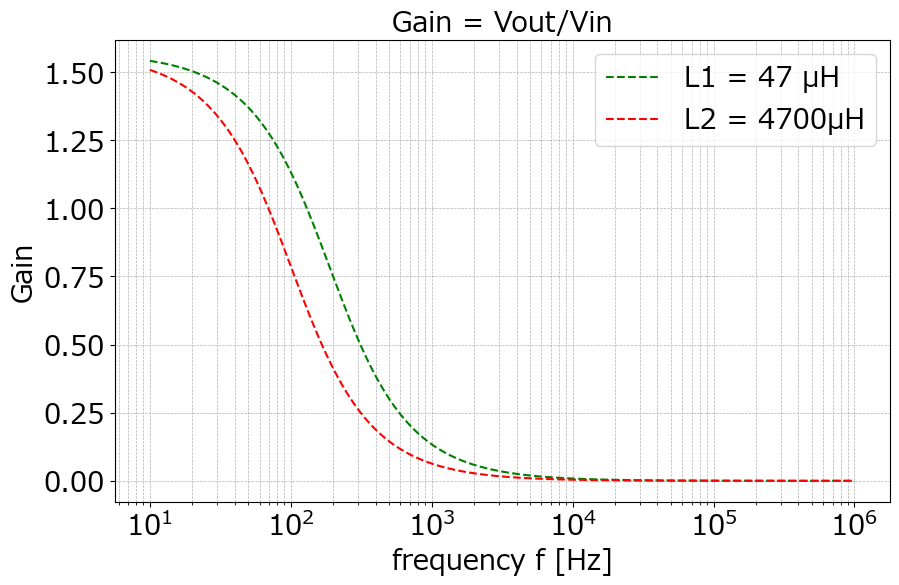

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# 抵抗 R [Ω]
R = 1000

# 周波数 f [Hz]（対数軸用に広範囲で設定）
f = np.logspace(1, 6, 500)  # 10 Hz 〜 1 MHz
omega = 2 * np.pi * f

# インダクタンス
L1 =47*10**-6   # 47μH
L2 = 4700*10**-6  # 4700 µH

# ゲイン
Gain1 =(R)/np.sqrt((R**2)+((omega*L1)**2))
Gain2 = (R)/np.sqrt((R**2)+((omega*L2)**2))

# グラフ描画
plt.figure(figsize=(10, 6))
plt.plot(f, theta1, color='green', linestyle='--',label='L1 = 47 µH')
plt.plot(f, theta2, color='red', linestyle='--', label='L2 = 4700µH')

plt.xscale('log')
plt.xlabel('frequency f [Hz]')
plt.ylabel('phase angle θ [rad]')
plt.title('Gain = Vout/Vin')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


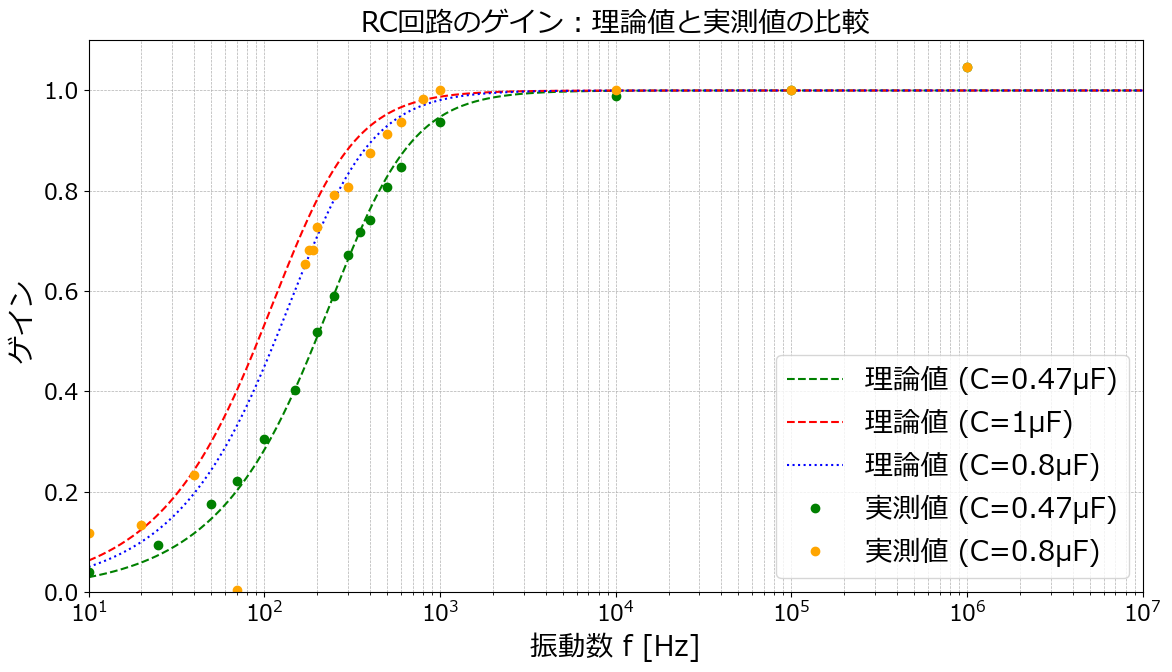

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 日本語フォントの設定 ---
# ご自身の環境に合ったフォント名またはパスを設定してください
# 例: 'Meiryo' (Windows), 'Hiragino Sans GB' (macOS), 'Noto Sans CJK JP' (Linux)
font_name = 'Meiryo' # 例: Windowsの場合

try:
    prop = fm.FontProperties(family=font_name)
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止
except Exception as e:
    print(f"Warning: Font setting failed. Error: {e}")
    print("Falling back to default font. Japanese characters might not display correctly.")
    # フォント設定が失敗した場合の代替
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False

# --- 実測値データ 1 (C=0.47µF) ---
# 振動数 [Hz] と gain のデータ (image_3f7fe2.png から手入力)
observed_frequency_0_47uF = np.array([
    10, 25, 50, 70, 100, 150, 200, 250, 300, 350, 400, 500, 600, 1000, 10000, 100000, 1000000
])
observed_gain_0_47uF = np.array([
    0.039604, 0.093333, 0.175676, 0.222222, 0.305455, 0.402985, 0.517647,
    0.590164, 0.670996, 0.718062, 0.740909, 0.806763, 0.847291, 0.937173,
    0.989418, 1, 1.047297
])

# --- 実測値データ 2 (C=0.8µF) ---
# 振動数 [Hz] と gain のデータ (image_3fe140.png から手入力)
observed_frequency_0_8uF = np.array([
    10, 20, 40, 70, 170, 180, 190, 200, 250, 300, 400, 500, 600, 800, 1000, 10000, 100000, 1000000
])
observed_gain_0_8uF = np.array([
    0.118227, 0.133333, 0.232877, 0.003731, 
    0.65368,0.682819, 0.682819, 0.727273, 0.791469, 0.806763,
    0.875, 0.913265, 0.937173, 0.983957, 1, 1, 1, 1.047297
])

# --- 理論値の計算 ---
R = 1000 # 抵抗 R [Ω]
f_theory = np.logspace(1, 7, 500) # 10 Hz 〜 10 MHz
omega_theory = 2 * np.pi * f_theory

C1 = 0.47 * 10**-6 # 0.47µF
C2 = 1.0 * 10**-6  # 1 µF
C3 = 0.8 * 10**-6  # 0.8 µF

# RCハイパス回路のゲインの理論式: Gain = R / sqrt(R^2 + X_C^2) = R / sqrt(R^2 + (1 / (omega * C))^2)
Gain_theory_C1 = R / np.sqrt(R**2 + (1 / (omega_theory * C1))**2)
Gain_theory_C2 = R / np.sqrt(R**2 + (1 / (omega_theory * C2))**2)
Gain_theory_C3 = R / np.sqrt(R**2 + (1 / (omega_theory * C3))**2)

# --- グラフ描画 ---
plt.figure(figsize=(12, 7))

# 理論値のプロット
plt.plot(f_theory, Gain_theory_C1, color='green', linestyle='--', linewidth=1.5, label='理論値 (C=0.47µF)')
plt.plot(f_theory, Gain_theory_C2, color='red', linestyle='--', linewidth=1.5, label='理論値 (C=1µF)')
plt.plot(f_theory, Gain_theory_C3, color='blue', linestyle=':', linewidth=1.5, label='理論値 (C=0.8µF)')

# 実測値のプロット (C=0.47µF)
plt.plot(observed_frequency_0_47uF, observed_gain_0_47uF, 'o', color='green', markersize=6, label='実測値 (C=0.47µF)')

# 実測値のプロット (C=0.8µF)
# 70Hzのデータ (0.003731) が非常に小さいので、プロット範囲からはみ出さないように注意
# データに異常値が含まれている可能性があるため、その点を考慮してください。
# ここでは一旦そのままプロットします。
plt.plot(observed_frequency_0_8uF, observed_gain_0_8uF, 'o', color='orange', markersize=6, label='実測値 (C=0.8µF)')


plt.xscale('log')
plt.xlabel('振動数 f [Hz]', fontsize=20)
plt.ylabel('ゲイン ', fontsize=20)
plt.title('RC回路のゲイン：理論値と実測値の比較', fontsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=20, loc='lower right') # 凡例の位置を調整
plt.xlim(10, 10**7) # X軸の範囲を調整
plt.ylim(0, 1.1) # Y軸の範囲を調整

plt.tight_layout() # レイアウトの調整
plt.show()

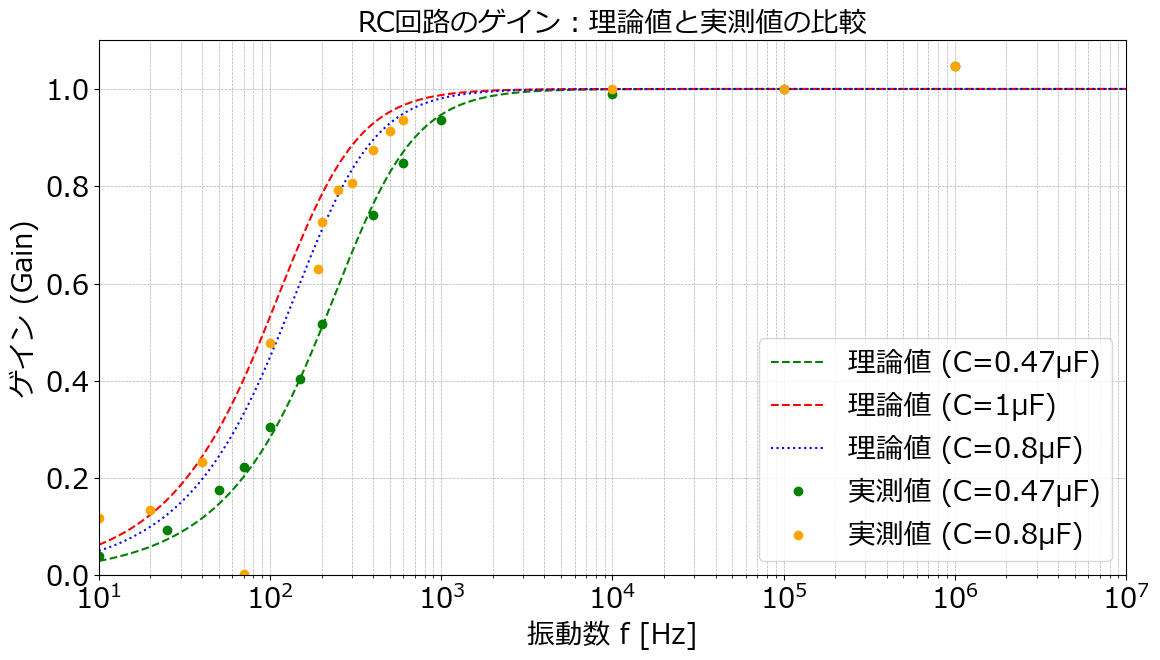

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 日本語フォントの設定 ---
# ご自身の環境に合ったフォント名またはパスを設定してください
# 例: 'Meiryo' (Windows), 'Hiragino Sans GB' (macOS), 'Noto Sans CJK JP' (Linux)
font_name = 'Meiryo' # 例: Windowsの場合
# プロット設定
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

try:
    prop = fm.FontProperties(family=font_name)
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止
except Exception as e:
    print(f"Warning: Font setting failed. Error: {e}")
    print("Falling back to default font. Japanese characters might not display correctly.")
    # フォント設定が失敗した場合の代替
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False

# --- 実測値データ 1 (C=0.47µF) ---
# 振動数 [Hz] と gain のデータ (image_3f7fe2.png から手入力)
observed_frequency_0_47uF = np.array([
    10, 25, 50, 70, 100, 150, 200,  400,  600, 1000, 10000, 100000, 1000000
])
observed_gain_0_47uF = np.array([
    0.039604, 0.093333, 0.175676, 0.222222, 0.305455, 0.402985, 0.517647, 0.740909, 0.847291, 0.937173,
    0.989418, 1, 1.047297
])

# --- 実測値データ 2 (C=0.8µF) ---
# 振動数 [Hz] と gain のデータ (image_3fe140.png から手入力)
observed_frequency_0_8uF = np.array([
    10, 20, 40, 70, 100, 190, 200, 250, 300, 400, 500, 600,  10000, 100000, 1000000
])
observed_gain_0_8uF = np.array([
    0.118227, 0.133333, 0.232877, 0.003731, 0.478088, 0.629787,0.727273, 0.791469, 0.806763,
    0.875, 0.913265, 0.937173,  1, 1, 1.047297
])

# --- 理論値の計算 ---
R = 1000 # 抵抗 R [Ω]
f_theory = np.logspace(1, 7, 500) # 10 Hz 〜 10 MHz
omega_theory = 2 * np.pi * f_theory

C1 = 0.47 * 10**-6 # 0.47µF
C2 = 1.0 * 10**-6  # 1 µF
C3 = 0.8 * 10**-6  # 0.8 µF

# RCハイパス回路のゲインの理論式: Gain = R / sqrt(R^2 + X_C^2) = R / sqrt(R^2 + (1 / (omega * C))^2)
Gain_theory_C1 = R / np.sqrt(R**2 + (1 / (omega_theory * C1))**2)
Gain_theory_C2 = R / np.sqrt(R**2 + (1 / (omega_theory * C2))**2)
Gain_theory_C3 = R / np.sqrt(R**2 + (1 / (omega_theory * C3))**2)

# --- グラフ描画 ---
plt.figure(figsize=(12, 7))

# 理論値のプロット
plt.plot(f_theory, Gain_theory_C1, color='green', linestyle='--', linewidth=1.5, label='理論値 (C=0.47µF)')
plt.plot(f_theory, Gain_theory_C2, color='red', linestyle='--', linewidth=1.5, label='理論値 (C=1µF)')
plt.plot(f_theory, Gain_theory_C3, color='blue', linestyle=':', linewidth=1.5, label='理論値 (C=0.8µF)')

# 実測値のプロット (C=0.47µF)
plt.plot(observed_frequency_0_47uF, observed_gain_0_47uF, 'o', color='green', markersize=6, label='実測値 (C=0.47µF)')

# 実測値のプロット (C=0.8µF)
# 70Hzのデータ (0.003731) が非常に小さいので、プロット範囲からはみ出さないように注意
# データに異常値が含まれている可能性があるため、その点を考慮してください。
# ここでは一旦そのままプロットします。
plt.plot(observed_frequency_0_8uF, observed_gain_0_8uF, 'o', color='orange', markersize=6, label='実測値 (C=0.8µF)')


plt.xscale('log')
plt.xlabel('振動数 f [Hz]', fontsize=20)
plt.ylabel('ゲイン (Gain)', fontsize=20)
plt.title('RC回路のゲイン：理論値と実測値の比較', fontsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=20, loc='lower right') # 凡例の位置を調整
plt.xlim(10, 10**7) # X軸の範囲を調整
plt.ylim(0, 1.1) # Y軸の範囲を調整

plt.tight_layout() # レイアウトの調整
plt.show()

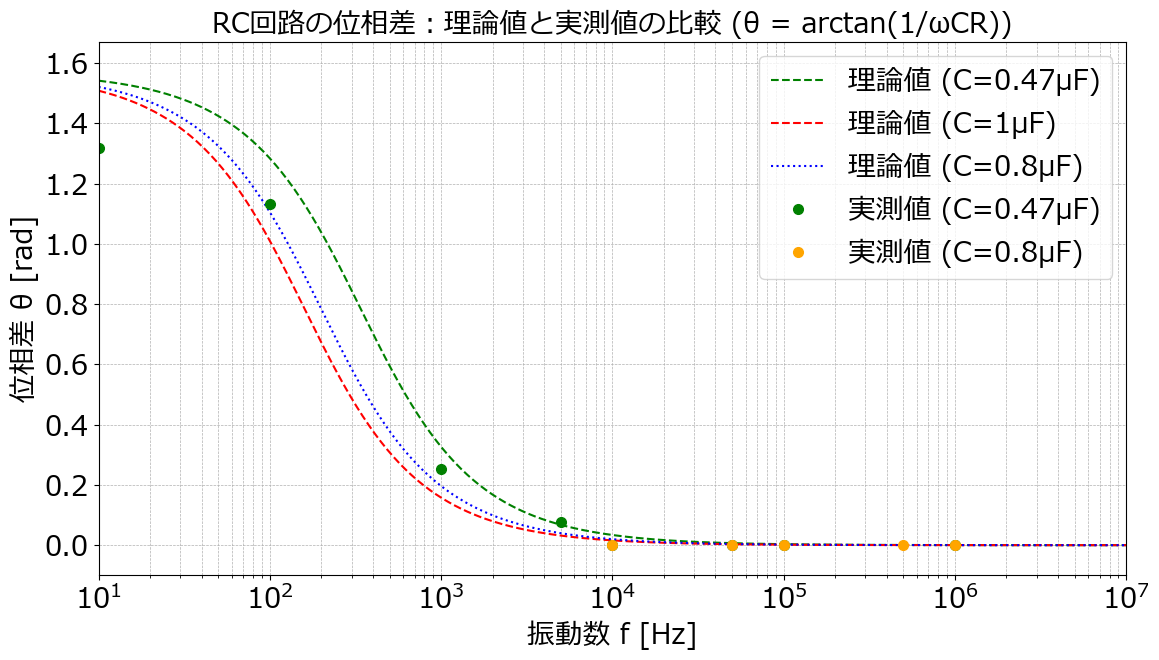

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 日本語フォントの設定 ---
# ご自身の環境に合ったフォント名またはパスを設定してください
font_name = 'Meiryo' # 例: Windowsの場合

# プロット設定
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

try:
    prop = fm.FontProperties(family=font_name)
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止
except Exception as e:
    print(f"Warning: Font setting failed. Error: {e}")
    print("Falling back to default font. Japanese characters might not display correctly.")
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False



# --- 実測値データ 2 (image_6a209e.pngから手入力) - C=0.47μF のデータとして重ねる
observed_phase_frequency_set2 = np.array([10, 100, 1000, 5000, 10000, 50000, 100000, 1000000])
observed_phase_difference_set2 = np.array([1.319469, 1.131, 0.251327, 0.07854, 0, 0, 0, 0])

# --- 実測値データ 3 (image_6a3383.pngから手入力) - C=0.8μF のデータとして重ねる
observed_phase_frequency_set3 = np.array([10000, 50000, 100000, 500000, 1000000])
observed_phase_difference_set3 = np.array([0, 0, 0, 0, 0])


# --- 理論値の計算 ---
R = 1000 # 抵抗 R [Ω]
f_theory = np.logspace(1, 7, 500) # 10 Hz 〜 10 MHz
omega_theory = 2 * np.pi * f_theory

C1 = 0.47 * 10**-6  # 0.47µF
C2 = 1.0 * 10**-6   # 1 µF
C3 = 0.8 * 10**-6   # 0.8 µF

# 位相角 θ をラジアンで計算 (ユーザー提供の式を使用: θ = arctan(1/ωCR))
theta1 = np.arctan(1 / (omega_theory * C1 * R))
theta2 = np.arctan(1 / (omega_theory * C2 * R))
theta3 = np.arctan(1 / (omega_theory * C3 * R))

# --- グラフ描画 ---
plt.figure(figsize=(12, 7))

# 理論値のプロット
plt.plot(f_theory, theta1, color='green', linestyle='--', linewidth=1.5, label='理論値 (C=0.47µF)')
plt.plot(f_theory, theta2, color='red', linestyle='--', linewidth=1.5, label='理論値 (C=1µF)')
plt.plot(f_theory, theta3, color='blue', linestyle=':', linewidth=1.5, label='理論値 (C=0.8µF)')

#

# 実測値のプロット 2 (image_6a209e.png由来、C=0.47µFと仮定)
plt.plot(observed_phase_frequency_set2, observed_phase_difference_set2, 'o', color='green', markersize=7, label='実測値 (C=0.47µF)')

# 実測値のプロット 3 (image_6a3383.png由来, C=0.8μF)
plt.plot(observed_phase_frequency_set3, observed_phase_difference_set3, 'o', color='orange', markersize=7, label='実測値 (C=0.8µF)')


plt.xscale('log')
plt.xlabel('振動数 f [Hz]', fontsize=20)
plt.ylabel('位相差 θ [rad]', fontsize=20)
plt.title('RC回路の位相差：理論値と実測値の比較 (θ = arctan(1/ωCR))', fontsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=20, loc='upper right') # 凡例の位置を調整

plt.xlim(10, 10**7) # X軸の範囲を調整
# Y軸の範囲をマイナスまで広げてゼロ値を見やすくする
plt.ylim(-0.1, np.pi / 2 + 0.1) # 下限を-0.1ラジアンに設定

plt.tight_layout() # レイアウトの調整
plt.show()

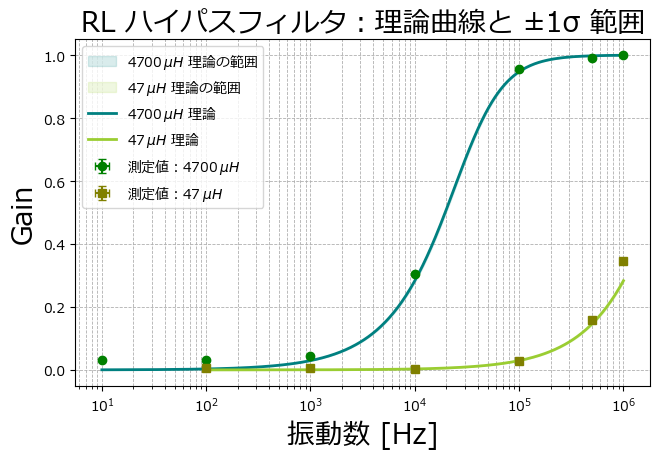

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# （日本語ラベルが必要なら）
try:
    import japanize_matplotlib
except ImportError:
    pass


# -------------------------------------------------
# 1. 伝達関数と不確かさ（RLハイパス）
# -------------------------------------------------
def rl_highpass_gain(f, L, R):
    """
    |H(jω)| = (ωL/R) / √(1 + (ωL/R)²)
    """
    ω  = 2 * np.pi * f
    X  = ω * L / R
    return X / np.sqrt(1 + X**2)


def rl_highpass_gain_uncertainty(f, L, R, tol_L=0.01, tol_R=0.01, tol_f=0.01):
    """
    1 次誤差伝播で ΔG を計算
      G = X / √(1+X²),  X = ωL/R
    """
    ω = 2 * np.pi * f
    X = ω * L / R
    G = X / np.sqrt(1 + X**2)

    dG_dX = 1 / (1 + X**2)**1.5          # ∂G/∂X
    dX_dL = ω / R                        # ∂X/∂L
    dX_dR = -ω * L / R**2               # ∂X/∂R
    dX_dω = L / R                       # ∂X/∂ω

    dL = tol_L * L
    dR = tol_R * R
    dω = tol_f * ω

    dG = np.sqrt((dG_dX * dX_dL * dL)**2 +
                 (dG_dX * dX_dR * dR)**2 +
                 (dG_dX * dX_dω * dω)**2)
    return G, dG


# -------------------------------------------------
# 2. 測定データ
# -------------------------------------------------
# L = 4700 µH
freq1 = np.array([10, 100, 1_000, 10_000, 100_000, 500_000, 1_000_000])
gain1 = np.array([0.031413613, 0.030434783, 0.042780749,
                  0.306122449, 0.955479452, 0.991731449, 1.0])

# L = 47 µH
freq2 = np.array([100, 1_000, 10_000, 100_000, 500_000, 1_000_000])
gain2 = np.array([0.006521739, 0.006521739, 0.003101604,
                  0.029518717, 0.159162304, 0.34698776])


# -------------------------------------------------
# 3. 名目パラメータとトレランス
# -------------------------------------------------
R_nom  = 1_000         # Ω
L1_nom = 4700e-6       # H
L2_nom = 47e-6         # H

tol_R = 0.01           # ±1 %
tol_L = 0.01           # ±1 %
tol_f = 0.01           # ±1 %


# -------------------------------------------------
# 4. 理論曲線と不確かさ帯
# -------------------------------------------------
f_th1 = np.logspace(np.log10(freq1.min()), np.log10(freq1.max()), 500)
G1_nom, dG1 = rl_highpass_gain_uncertainty(
    f_th1, L1_nom, R_nom, tol_L, tol_R, tol_f)

f_th2 = np.logspace(np.log10(freq2.min()), np.log10(freq2.max()), 500)
G2_nom, dG2 = rl_highpass_gain_uncertainty(
    f_th2, L2_nom, R_nom, tol_L, tol_R, tol_f)


# 測定点の不確かさ
_, dG_meas1 = rl_highpass_gain_uncertainty(
    freq1, L1_nom, R_nom, tol_L, tol_R, tol_f)
_, dG_meas2 = rl_highpass_gain_uncertainty(
    freq2, L2_nom, R_nom, tol_L, tol_R, tol_f)

dF1 = tol_f * freq1    # 周波数方向 ±1 %
dF2 = tol_f * freq2


# -------------------------------------------------
# 5. プロット
# -------------------------------------------------
plt.figure(figsize=(7, 5))

# ── 理論 ±1σ 帯 ──
plt.fill_between(f_th1, np.clip(G1_nom - dG1, 0, 1),
                 np.clip(G1_nom + dG1, 0, 1),
                 color='teal', alpha=0.15, label='4700$ µH$ 理論の範囲')
plt.fill_between(f_th2, np.clip(G2_nom - dG2, 0, 1),
                 np.clip(G2_nom + dG2, 0, 1),
                 color='yellowgreen', alpha=0.15, label='47$ µH$ 理論の範囲 ')

# ── 理論 nominal 曲線 ──
plt.plot(f_th1, G1_nom, color='teal', linewidth=2, label='4700$ µH$ 理論')
plt.plot(f_th2, G2_nom, color='yellowgreen', linewidth=2, label='47$ µH$ 理論')

# ── 測定点 + 誤差棒 ──
plt.errorbar(freq1, gain1, yerr=dG_meas1, xerr=dF1,
             fmt='o', color='green', capsize=3, label='測定値：4700$ µH$')
plt.errorbar(freq2, gain2, yerr=dG_meas2, xerr=dF2,
             fmt='s', color='olive', capsize=3, label='測定値：47$ µH$')

# 体裁
plt.xscale('log')
plt.xlabel('振動数 [Hz]')
plt.ylabel('Gain')
plt.title('RL ハイパスフィルタ：理論曲線と ±1σ 範囲')
plt.grid(True, which='both', linestyle='--', linewidth=0.6)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

C:\Users\jupik\AppData\Local\Temp\ipykernel_2884\3565316418.py:121: UserWarning: Glyph 8239 (\N{NARROW NO-BREAK SPACE}) missing from current font.
  plt.tight_layout()
\\?\C:\Users\jupik\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8239 (\N{NARROW NO-BREAK SPACE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


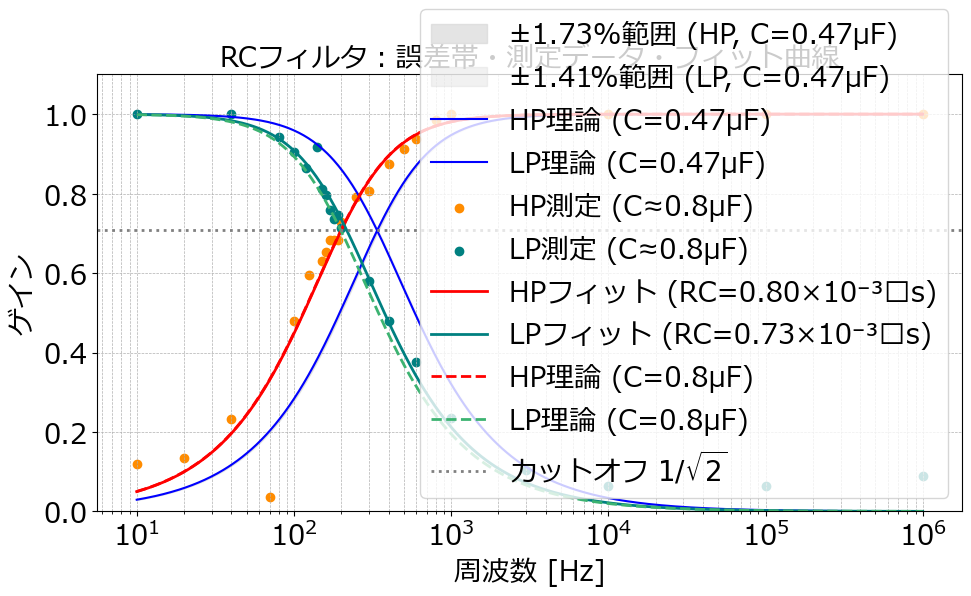

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 日本語ラベルを使う場合は（フォントが入っていれば）有効化
try:
    import japanize_matplotlib
except ImportError:
    pass

# -------------------------------------------------
# 1. 誤差帯を描く (R = 1 kΩ, C = 0.47 µF)
# -------------------------------------------------
R        = 1_000                     # Ω
C_err    = 0.47e-6                   # F
RC_err   = R * C_err                 # 時定数
delta_hp = 0.0173                    # ±1.73 %
delta_lp = 0.0141                    # ±1.41 %

# 周波数軸（10 Hz – 1 MHz）
f  = np.logspace(1, 6, 500)          # Hz

def highpass_gain(f, RC):
    return 2*np.pi*f*RC / np.sqrt(1 + (2*np.pi*f*RC)**2)

def lowpass_gain(f, RC):
    return 1 / np.sqrt(1 + (2*np.pi*f*RC)**2)

# 誤差帯 (C = 0.47 µF)
hp_center = highpass_gain(f, RC_err)
hp_min    = highpass_gain(f, RC_err * (1 - delta_hp))
hp_max    = highpass_gain(f, RC_err * (1 + delta_hp))

lp_center = lowpass_gain(f, RC_err)
lp_min    = lowpass_gain(f, RC_err * (1 + delta_lp))  # RC↑ → ゲイン↑
lp_max    = lowpass_gain(f, RC_err * (1 - delta_lp))  # RC↓ → ゲイン↓

# -------------------------------------------------
# 2. 実測データ (R = 1 kΩ, C ≃ 0.8 µF)
# -------------------------------------------------
# --- ハイパス ---
freq_hp = np.array([
    10, 20, 40, 70, 100, 125, 150, 160, 170, 180, 190, 200,
    250, 300, 400, 500, 600, 800, 1000, 10000, 100000, 1000000])
gain_hp_m = np.array([
    0.118226601, 0.133333333, 0.232876712, 0.03731343, 0.478087649, 0.593886463,
    0.629787234, 0.653679654, 0.682819383, 0.682819383, 0.682819383, 0.727272727,
    0.791469194, 0.806763285, 0.875, 0.913265306, 0.937172775, 0.983957219,
    1, 1, 1, 1])

# --- ローパス ---
freq_lp = np.array([
    10, 40, 80, 100, 120, 140, 150, 160, 170, 180, 190, 200,
    300, 400, 600, 1000, 3000, 10000, 100000, 1000000])
gain_lp_m = np.array([
    1, 1, 0.941176471, 0.90438247, 0.864754098, 0.916666667, 0.812765957,
    0.796536797, 0.757575758, 0.735682819, 0.745535714, 0.714285714,
    0.579710145, 0.48, 0.376963351, 0.235294118, 0.104712042,
    0.064171123, 0.062827225, 0.089385475])

# 名目値 (C = 0.8 µF)
C_fixed  = 0.8e-6
RC_fixed = R * C_fixed

# フィッティング
popt_hp, _ = curve_fit(highpass_gain, freq_hp, gain_hp_m, p0=[RC_fixed])
RC_fit_hp  = popt_hp[0]

popt_lp, _ = curve_fit(lowpass_gain, freq_lp, gain_lp_m, p0=[RC_fixed])
RC_fit_lp  = popt_lp[0]

# 曲線（フィット・名目）
hp_fit   = highpass_gain(f, RC_fit_hp)
hp_fixed = highpass_gain(f, RC_fixed)
lp_fit   = lowpass_gain(f, RC_fit_lp)
lp_fixed = lowpass_gain(f, RC_fixed)

# -------------------------------------------------
# 3. プロット
# -------------------------------------------------
plt.figure(figsize=(10, 6))

# 誤差帯（色は lightgray のまま、透明度だけ変えて重なりを見やすく）
plt.fill_between(f, hp_min, hp_max, color='lightgray', alpha=0.6,
                 label='±1.73%範囲 (HP, C=0.47µF)')
plt.fill_between(f, lp_min, lp_max, color='lightgray', alpha=0.3,
                 label='±1.41%範囲 (LP, C=0.47µF)')

# 中央理論線 (C = 0.47 µF) ―― 青
plt.plot(f, hp_center, 'b', label='HP理論 (C=0.47µF)')
plt.plot(f, lp_center, 'b', label='LP理論 (C=0.47µF)')

# 実測データ
plt.scatter(freq_hp, gain_hp_m, color='darkorange', label='HP測定 (C≈0.8µF)')
plt.scatter(freq_lp, gain_lp_m, color='teal',       label='LP測定 (C≈0.8µF)')

# フィット曲線
plt.plot(f, hp_fit, color='red', linewidth=2,
         label=f'HPフィット (RC={RC_fit_hp*1e3:.2f}×10⁻³ s)')
plt.plot(f, lp_fit, color='teal',   linewidth=2,
         label=f'LPフィット (RC={RC_fit_lp*1e3:.2f}×10⁻³ s)')

# 名目理論 (C=0.8 µF) ―― 破線
plt.plot(f, hp_fixed, color='red',           linestyle='--', linewidth=2,
         label='HP理論 (C=0.8µF)')
plt.plot(f, lp_fixed, color='mediumseagreen', linestyle='--', linewidth=2,
         label='LP理論 (C=0.8µF)')

# カットオフライン
cutoff_gain = 1/np.sqrt(2)
plt.axhline(cutoff_gain, color='gray', linestyle=':', linewidth=2,
            label=r'カットオフ $1/\sqrt{2}$')

plt.xscale('log')
plt.xlabel('周波数 [Hz]')
plt.ylabel('ゲイン')
plt.title('RCフィルタ：誤差帯・測定データ・フィット曲線')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0, 1.1)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

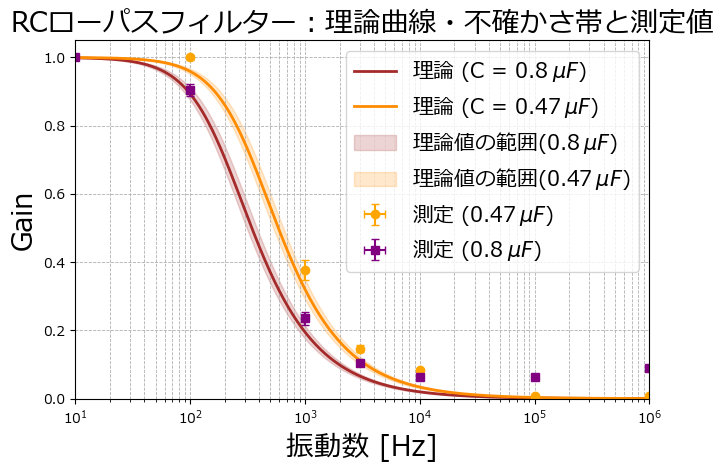

In [8]:
import numpy as np
import matplotlib.pyplot as plt
# （日本語ラベルを使う環境なら）
try:
    import japanize_matplotlib
except ImportError:
    pass

# ---------------------------------------------------
# 1. 測定データ
# ---------------------------------------------------
# C = 0.47 µF
freq_047 = np.array([100, 1_000, 3_000, 10_000, 100_000, 1_000_000])
gain_047 = np.array([1, 0.376963351, 0.146596859, 0.083769634,
                     0.006282723, 0.006521739])

# C = 0.8 µF
freq_08  = np.array([10, 100, 1_000, 3_000, 10_000, 100_000, 1_000_000])
gain_08  = np.array([1, 0.90438247, 0.235294118, 0.104712042,
                     0.064171123, 0.062827225, 0.089385475])

# ---------------------------------------------------
# 2. パラメータと誤差（トレランス）
# ---------------------------------------------------
R   = 1_000          # Ω
tol_R = 0.01         # ±1 %
tol_C = 0.10         # ±10 %
tol_f = 0.01         # ±1 %

C_047 = 0.47e-6      # F
C_08  = 0.80e-6      # F

# ---------------------------------------------------
# 3. 伝達関数と不確かさ伝播
# ---------------------------------------------------
def lowpass_gain(f, R, C):
    """|H(jω)| = 1 / √(1 + (ωRC)^2)"""
    w = 2 * np.pi * f
    return 1 / np.sqrt(1 + (w * R * C) ** 2)

def lowpass_gain_uncertainty(f, R, C, tol_R, tol_C, tol_f):
    """
    ΔG を１次誤差伝播で計算
      G = (1 + X^2)^{−1/2},  X = ωRC
      dG/dX = −X (1 + X^2)^{−3/2}
    """
    w = 2 * np.pi * f
    X = w * R * C
    G = 1 / np.sqrt(1 + X**2)

    # 偏微分
    dG_dX = -X / (1 + X**2)**1.5
    dX_dR = w * C
    dX_dC = w * R
    dX_dw = R * C

    # 各パラメータの絶対誤差
    dR = tol_R * R
    dC = tol_C * C
    dw = tol_f * w      # ω は f に比例

    # 合成不確かさ
    dG = np.sqrt((dG_dX * dX_dR * dR)**2 +
                 (dG_dX * dX_dC * dC)**2 +
                 (dG_dX * dX_dw * dw)**2)
    return G, dG

# 理論周波数軸
f_theory = np.logspace(1, 6, 500)   # 10 Hz – 1 MHz

# 理論ゲインと不確かさ帯
G47, dG47 = lowpass_gain_uncertainty(f_theory, R, C_047,
                                     tol_R, tol_C, tol_f)
G08, dG08 = lowpass_gain_uncertainty(f_theory, R, C_08,
                                     tol_R, tol_C, tol_f)

# ---------------------------------------------------
# 4. 測定点の不確かさ（縦: ΔG, 横: Δf）
#     ─ 理論式と同じパラメータ伝播で縦方向を算出
# ---------------------------------------------------
_, dG_meas_047 = lowpass_gain_uncertainty(freq_047, R, C_047,
                                          tol_R, tol_C, tol_f)
_, dG_meas_08  = lowpass_gain_uncertainty(freq_08,  R, C_08,
                                          tol_R, tol_C, tol_f)
dF_047 = tol_f * freq_047      # ±1 %  (横誤差)
dF_08  = tol_f * freq_08

# ---------------------------------------------------
# 5. プロット
# ---------------------------------------------------
plt.figure(figsize=(7, 5))

# ─── 理論曲線（色はそのまま） ───
plt.plot(f_theory, G08,  color='brown', linewidth=2,
         label='理論 (C = 0.8$ µF$)')
plt.plot(f_theory, G47,  color='darkorange',  linewidth=2,
         label='理論 (C = 0.47$ µF$)')

# ─── 不確かさ帯 (±1σ) ───
plt.fill_between(f_theory, np.clip(G08 - dG08, 0, 1),
                 np.clip(G08 + dG08, 0, 1),
                 color='brown', alpha=0.2,
                 label='理論値の範囲(0.8$ µF$)')
plt.fill_between(f_theory, np.clip(G47 - dG47, 0, 1),
                 np.clip(G47 + dG47, 0, 1),
                 color='darkorange', alpha=0.2,
                 label='理論値の範囲(0.47$ µF$)')

# ─── 測定点＋誤差棒 ───
plt.errorbar(freq_047, gain_047, yerr=dG_meas_047, xerr=dF_047,
             fmt='o', color='orange', capsize=3, label='測定 (0.47$ µF$)')
plt.errorbar(freq_08,  gain_08,  yerr=dG_meas_08,  xerr=dF_08,
             fmt='s', color='purple',   capsize=3, label='測定 (0.8$ µF$)')

# フォントサイズ（**先に設定しておくと確実**）
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 20,
    'axes.labelsize': 17,
    'legend.fontsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
})

# 軸と体裁
plt.xscale('log')
plt.xlim(10, 1e6)
plt.ylim(0, 1.05)
plt.xlabel('振動数 [Hz]')
plt.ylabel('Gain')
plt.title('RCローパスフィルター：理論曲線・不確かさ帯と測定値')
plt.grid(True, which='both', linestyle='--', linewidth=0.6)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


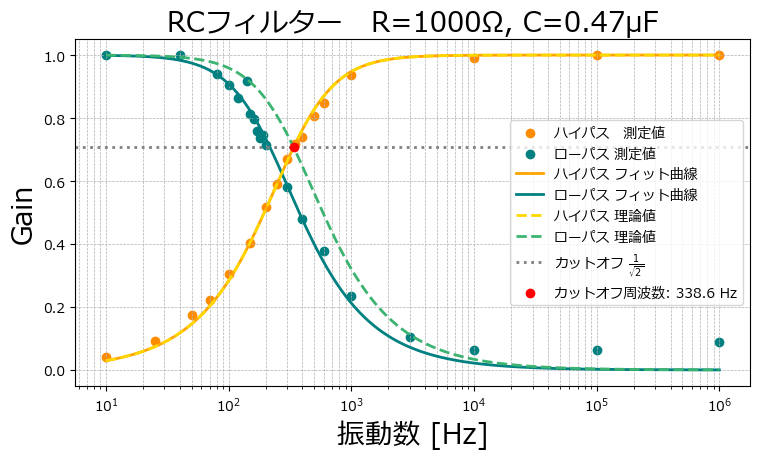

In [5]:
#(R=1000Ω, C=0.48μF)ハイパスフィルターとローパスフィルター
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 日本語フォントの設定 ---
# ご自身の環境に合ったフォント名またはパスを設定してください
font_name = 'Meiryo' # 例: Windowsの場合

# プロット設定
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

try:
    prop = fm.FontProperties(family=font_name)
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止
except Exception as e:
    print(f"Warning: Font setting failed. Error: {e}")
    print("Falling back to default font. Japanese characters might not display correctly.")
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False

from scipy.optimize import curve_fit

# --- ハイパスフィルタ 実測データ ---
freq_hp = np.array([
    10, 25, 50, 70, 100, 150, 200, 250, 300, 350, 400, 500,
    600, 1000, 10000, 100000, 1000000
])
gain_hp = np.array([
    0.03960396, 0.093333333, 0.175675676, 0.222222222, 0.305454545,
    0.402985075, 0.517647059, 0.590163934, 0.670995671, 0.718061674,
    0.740909091, 0.806763285, 0.84729064, 0.937172775,
    0.989417989, 1,1
])
# --- ローパスフィルタ 実測データ ---
freq_lp = np.array([10, 40, 80, 100, 120, 140, 150, 160, 170, 180, 190, 200,
                 300, 400, 600, 1000, 3000, 10000, 100000, 1000000])
gain_lp = np.array([1, 1, 0.941176471, 0.90438247, 0.864754098, 0.916666667,
                 0.812765957, 0.796536797, 0.757575758, 0.735682819, 0.745535714,
                 0.714285714, 0.579710145, 0.48, 0.376963351, 0.235294118,
                 0.104712042, 0.064171123, 0.062827225, 0.089385475])


# --- 理論モデル ---
def highpass_gain(f, RC):
    omega = 2 * np.pi * f
    return (omega * RC) / np.sqrt(1 + (omega * RC)**2)

def lowpass_gain(f, RC):
    omega = 2 * np.pi * f
    return 1 / np.sqrt(1 + (omega * RC)**2)

# --- フィッティング ---
popt_hp, _ = curve_fit(highpass_gain, freq_hp, gain_hp, p0=[1e-3])
RC_fit_hp = popt_hp[0]

popt_lp, _ = curve_fit(lowpass_gain, freq_lp, gain_lp, p0=[1e-4])
RC_fit_lp = popt_lp[0]

# --- 固定パラメータ ---
R_fixed = 1000
C_fixed_hp = 0.47e-6
RC_fixed_hp = R_fixed * C_fixed_hp

C_fixed_lp = 0.47e-6
RC_fixed_lp = R_fixed * C_fixed_lp

# --- 周波数軸 ---
f_fit = np.logspace(1, 6, 500)

# --- 理論曲線計算 ---
gain_hp_fit = highpass_gain(f_fit, RC_fit_hp)
gain_hp_fixed = highpass_gain(f_fit, RC_fixed_hp)

gain_lp_fit = lowpass_gain(f_fit, RC_fit_lp)
gain_lp_fixed = lowpass_gain(f_fit, RC_fixed_lp)

# --- カットオフ周波数 ---
cutoff_gain = 1 / np.sqrt(2)
fc_hp_fit = 1 / (2 * np.pi * RC_fit_hp)
fc_hp_fixed = 1 / (2 * np.pi * RC_fixed_hp)
fc_lp_fit = 1 / (2 * np.pi * RC_fit_lp)
fc_lp_fixed = 1 / (2 * np.pi * RC_fixed_lp)

# --- プロット ---
plt.figure(figsize=(8, 5))

# 実測値
plt.scatter(freq_hp, gain_hp, color='darkorange', label='ハイパス　測定値')
plt.scatter(freq_lp, gain_lp, color='teal', label='ローパス 測定値')

# フィット曲線
plt.plot(f_fit, gain_hp_fit, color='orange', linewidth=2, label=f'ハイパス フィット曲線 ')
plt.plot(f_fit, gain_lp_fit, color='teal', linewidth=2, label=f'ローパス フィット曲線 ')

# 固定理論曲線
plt.plot(f_fit, gain_hp_fixed, color='gold', linestyle='--', linewidth=2, label='ハイパス 理論値 ')
plt.plot(f_fit, gain_lp_fixed, color='mediumseagreen', linestyle='--', linewidth=2, label='ローパス 理論値 ')

# カットオフライン
plt.axhline(cutoff_gain, color='gray', linestyle=':', linewidth=2, label=r'カットオフ $\frac{1}{\sqrt{2}}$')

# 交点マーカー
#plt.scatter(fc_hp_fit, cutoff_gain, color='red', edgecolor='black', zorder=5,
           # label=f'ハイパス 交点（フィット）: {fc_hp_fit:.1f} Hz')
#plt.scatter(fc_hp_fixed, cutoff_gain, color='orangered', edgecolor='black', zorder=5,
           # label=f'ハイパス 交点（固定）: {fc_hp_fixed:.1f} Hz')
#plt.scatter(fc_lp_fit, cutoff_gain, color='blue', edgecolor='black', zorder=5,
           # label=f'ローパス 交点（フィット）: {fc_lp_fit:.1f} Hz')
plt.scatter(fc_lp_fixed, cutoff_gain, color='red', edgecolor='red', zorder=7,
            label=f'カットオフ周波数: {fc_lp_fixed:.1f} Hz')

plt.xscale('log')
plt.xlabel('振動数 [Hz]')
plt.ylabel('Gain')
plt.title('RCフィルター　R=1000Ω, C=0.47μF')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()



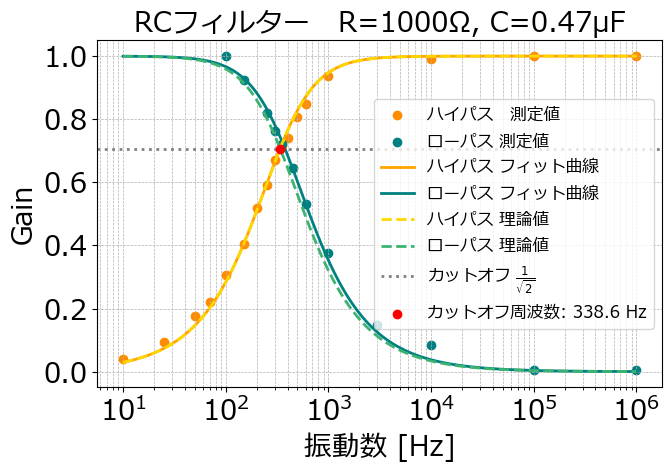

In [10]:
#(R=1000Ω, C=0.48μF)ハイパスフィルターとローパスフィルター
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 日本語フォントの設定 ---
font_name = 'Meiryo' # 例: Windowsの場合
# プロット設定
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# --- ハイパスフィルタ 実測データ ---
freq_hp = np.array([
    10, 25, 50, 70, 100, 150, 200, 250, 300, 350, 400, 500,
    600, 1000, 10000, 100000, 1000000
])
gain_hp = np.array([
    0.03960396, 0.093333333, 0.175675676, 0.222222222, 0.305454545,
    0.402985075, 0.517647059, 0.590163934, 0.670995671, 0.718061674,
    0.740909091, 0.806763285, 0.84729064, 0.937172775,
    0.989417989, 1,1
])
# --- ローパスフィルタ 実測データ ---
freq_lp = np.array([100,
150,
250,
300,
350,
450,
600,
1000,
3000,
10000,
100000,
1000000])
gain_lp = np.array([1,
0.922794118,
0.819672131,
0.761702128,
0.72246696,
0.644549763,
0.532019704,
0.376963351,
0.146596859,
0.083769634,
0.006282723,
0.006521739,
])


# --- 理論モデル ---
def highpass_gain(f, RC):
    omega = 2 * np.pi * f
    return (omega * RC) / np.sqrt(1 + (omega * RC)**2)

def lowpass_gain(f, RC):
    omega = 2 * np.pi * f
    return 1 / np.sqrt(1 + (omega * RC)**2)

# --- フィッティング ---
popt_hp, _ = curve_fit(highpass_gain, freq_hp, gain_hp, p0=[1e-3])
RC_fit_hp = popt_hp[0]

popt_lp, _ = curve_fit(lowpass_gain, freq_lp, gain_lp, p0=[1e-4])
RC_fit_lp = popt_lp[0]

# --- 固定パラメータ ---
R_fixed = 1000
C_fixed_hp = 0.47e-6
RC_fixed_hp = R_fixed * C_fixed_hp

C_fixed_lp = 0.47e-6
RC_fixed_lp = R_fixed * C_fixed_lp

# --- 周波数軸 ---
f_fit = np.logspace(1, 6, 500)

# --- 理論曲線計算 ---
gain_hp_fit = highpass_gain(f_fit, RC_fit_hp)
gain_hp_fixed = highpass_gain(f_fit, RC_fixed_hp)

gain_lp_fit = lowpass_gain(f_fit, RC_fit_lp)
gain_lp_fixed = lowpass_gain(f_fit, RC_fixed_lp)

# --- カットオフ周波数 ---
cutoff_gain = 1 / np.sqrt(2)
fc_hp_fit = 1 / (2 * np.pi * RC_fit_hp)
fc_hp_fixed = 1 / (2 * np.pi * RC_fixed_hp)
fc_lp_fit = 1 / (2 * np.pi * RC_fit_lp)
fc_lp_fixed = 1 / (2 * np.pi * RC_fixed_lp)

# --- プロット ---
plt.figure(figsize=(7, 5))

# 実測値
plt.scatter(freq_hp, gain_hp, color='darkorange', label='ハイパス　測定値')
plt.scatter(freq_lp, gain_lp, color='teal', label='ローパス 測定値')

# フィット曲線
plt.plot(f_fit, gain_hp_fit, color='orange', linewidth=2, label=f'ハイパス フィット曲線 ')
plt.plot(f_fit, gain_lp_fit, color='teal', linewidth=2, label=f'ローパス フィット曲線 ')

# 固定理論曲線
plt.plot(f_fit, gain_hp_fixed, color='gold', linestyle='--', linewidth=2, label='ハイパス 理論値 ')
plt.plot(f_fit, gain_lp_fixed, color='mediumseagreen', linestyle='--', linewidth=2, label='ローパス 理論値 ')

# カットオフライン
plt.axhline(cutoff_gain, color='gray', linestyle=':', linewidth=2, label=r'カットオフ $\frac{1}{\sqrt{2}}$')

# 交点マーカー
#plt.scatter(fc_hp_fit, cutoff_gain, color='red', edgecolor='black', zorder=5,
           # label=f'ハイパス 交点（フィット）: {fc_hp_fit:.1f} Hz')
#plt.scatter(fc_hp_fixed, cutoff_gain, color='orangered', edgecolor='black', zorder=5,
           # label=f'ハイパス 交点（固定）: {fc_hp_fixed:.1f} Hz')
#plt.scatter(fc_lp_fit, cutoff_gain, color='blue', edgecolor='black', zorder=5,
           # label=f'ローパス 交点（フィット）: {fc_lp_fit:.1f} Hz')
plt.scatter(fc_lp_fixed, cutoff_gain, color='red', edgecolor='red', zorder=7,
            label=f'カットオフ周波数: {fc_lp_fixed:.1f} Hz')

plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

plt.xscale('log')
plt.xlabel('振動数 [Hz]')
plt.ylabel('Gain')
plt.title('RCフィルター　R=1000Ω, C=0.47μF')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

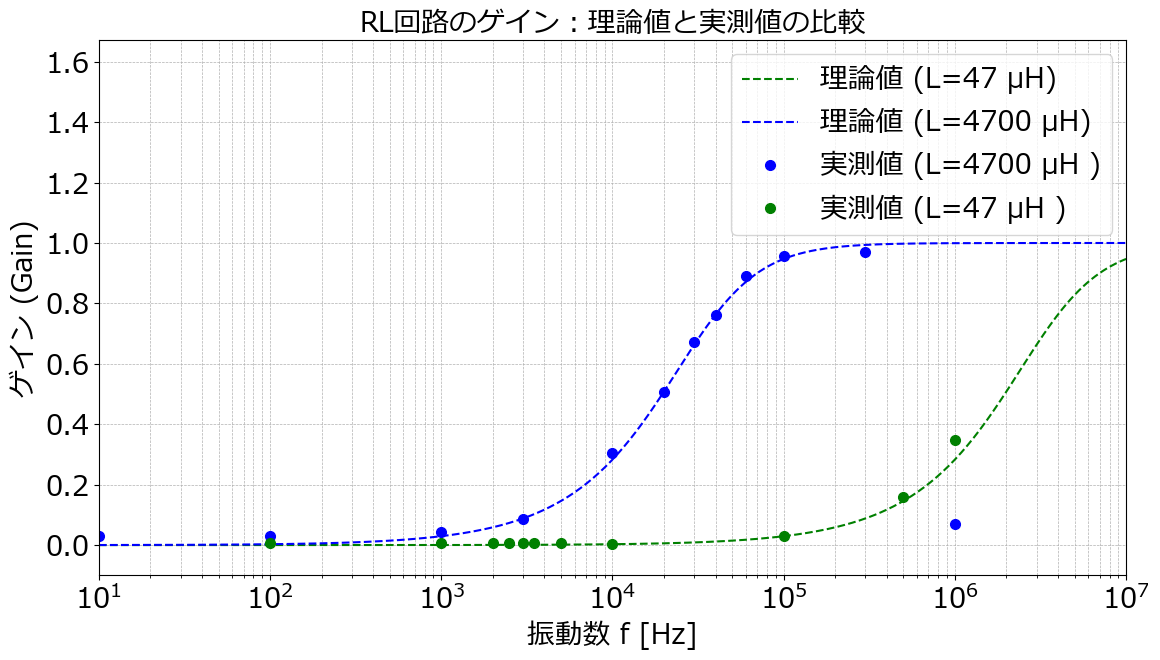

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 日本語フォントの設定 ---
font_name = 'Meiryo' # 例: Windowsの場合
# プロット設定
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

try:
    prop = fm.FontProperties(family=font_name)
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止
except Exception as e:
    print(f"Warning: Font setting failed. Error: {e}")
    print("Falling back to default font. Japanese characters might not display correctly.")
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False

# 抵抗 R [Ω]
R = 1000

# 周波数 f [Hz]（対数軸用に広範囲で設定）
f_theory = np.logspace(1, 7, 500)  # 10 Hz 〜 10 MHz
omega_theory = 2 * np.pi * f_theory

# インダクタンス
L1 = 47 * 10**-6    # 47 µH
L2 = 4700 * 10**-6  # 4700 µH (4.7 mH)

# RLハイパス回路のゲインを計算: Vout/Vin = (omega*L) / sqrt(R^2 + (omega*L)^2)
Gain_L1_theory = (omega_theory * L1) / np.sqrt((R**2) + ((omega_theory * L1)**2))
Gain_L2_theory = (omega_theory * L2) / np.sqrt((R**2) + ((omega_theory * L2)**2))

# --- 実測値データ 1 (image_76f124.pngより) ---
# RLハイパス回路、L=4700µHに対応
observed_freq_RL_HP_L2 = np.array([10, 100, 1000, 3000, 10000, 20000, 30000, 40000, 60000, 100000, 300000, 1000000])
observed_gain_RL_HP_L2 = np.array([0.031414, 0.030435, 0.042781, 0.087701, 0.306122, 0.507389, 0.672727, 0.761702, 0.891892, 0.955479, 0.971731, 0.069898])

# --- 新しい実測値データ 2 (image_775edd.pngより) ---
# RLハイパス回路、L=47µHに対応
observed_freq_RL_HP_L1 = np.array([100, 1000, 2000, 2500, 3000, 3500, 5000, 10000, 100000, 500000, 1000000])
observed_gain_RL_HP_L1 = np.array([0.006522, 0.006522, 0.006417, 0.006417, 0.006417, 0.006417, 0.006417, 0.003102, 0.029519, 0.159162, 0.346939])

# --- グラフ描画 ---
plt.figure(figsize=(12, 7))

# 理論値のプロット
plt.plot(f_theory, Gain_L1_theory, color='green', linestyle='--', linewidth=1.5, label='理論値 (L=47 µH)')
plt.plot(f_theory, Gain_L2_theory, color='blue', linestyle='--', linewidth=1.5, label='理論値 (L=4700 µH)')

# 実測値のプロット 1 (image_76f124.pngのデータ - L=4700µHに対応)
plt.plot(observed_freq_RL_HP_L2, observed_gain_RL_HP_L2, 'o', color='blue', markersize=7, label='実測値 (L=4700 µH )')

# 新しい実測値のプロット 2 (image_775edd.pngのデータ - L=47µHに対応)
plt.plot(observed_freq_RL_HP_L1, observed_gain_RL_HP_L1, 'o', color='green', markersize=7, label='実測値 (L=47 µH )')

plt.xscale('log')
plt.xlabel('振動数 f [Hz]', fontsize=20)
plt.ylabel('ゲイン (Gain)', fontsize=20)
plt.title('RL回路のゲイン：理論値と実測値の比較', fontsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=20)
plt.ylim(0, 1.1) # ゲインの範囲を0から1.1に固定
plt.xlim(10, 10**7) # 周波数範囲を実測値に合わせて調整
# Y軸の範囲をマイナスまで広げてゼロ値を見やすくする
plt.ylim(-0.1, np.pi / 2 + 0.1) # 下限を-0.1ラジアンに設定

plt.tight_layout()
plt.show()

In [12]:
import numpy as np

# 抵抗 R [Ω]
R = 1000

# インダクタンス
L1 = 47 * 10**-6    # 47 µH
L2 = 4700 * 10**-6  # 4700 µH (4.7 mH)

# 計算したい周波数
f_calc_1 = 50000  # Hz
f_calc_2 = 100000 # Hz

# 各周波数での角周波数
omega_calc_1 = 2 * np.pi * f_calc_1
omega_calc_2 = 2 * np.pi * f_calc_2

# RLハイパス回路のゲインの理論式: Gain = (omega*L) / sqrt(R^2 + (omega*L)^2)

# L1 = 47 µH の場合
Gain_L1_at_50000Hz = (omega_calc_1 * L1) / np.sqrt((R**2) + ((omega_calc_1 * L1)**2))
Gain_L1_at_100000Hz = (omega_calc_2 * L1) / np.sqrt((R**2) + ((omega_calc_2 * L1)**2))

# L2 = 4700 µH (4.7 mH) の場合
Gain_L2_at_50000Hz = (omega_calc_1 * L2) / np.sqrt((R**2) + ((omega_calc_1 * L2)**2))
Gain_L2_at_100000Hz = (omega_calc_2 * L2) / np.sqrt((R**2) + ((omega_calc_2 * L2)**2))

print(f"--- 50000 Hz でのゲイン ---")
print(f"L=47 µH:   {Gain_L1_at_50000Hz:.3f}")
print(f"L=4700 µH: {Gain_L2_at_50000Hz:.3f}")
print(f"\n--- 100000 Hz でのゲイン ---")
print(f"L=47 µH:   {Gain_L1_at_100000Hz:.3f}")
print(f"L=4700 µH: {Gain_L2_at_100000Hz:.3f}")

--- 50000 Hz でのゲイン ---
L=47 µH:   0.015
L=4700 µH: 0.828

--- 100000 Hz でのゲイン ---
L=47 µH:   0.030
L=4700 µH: 0.947


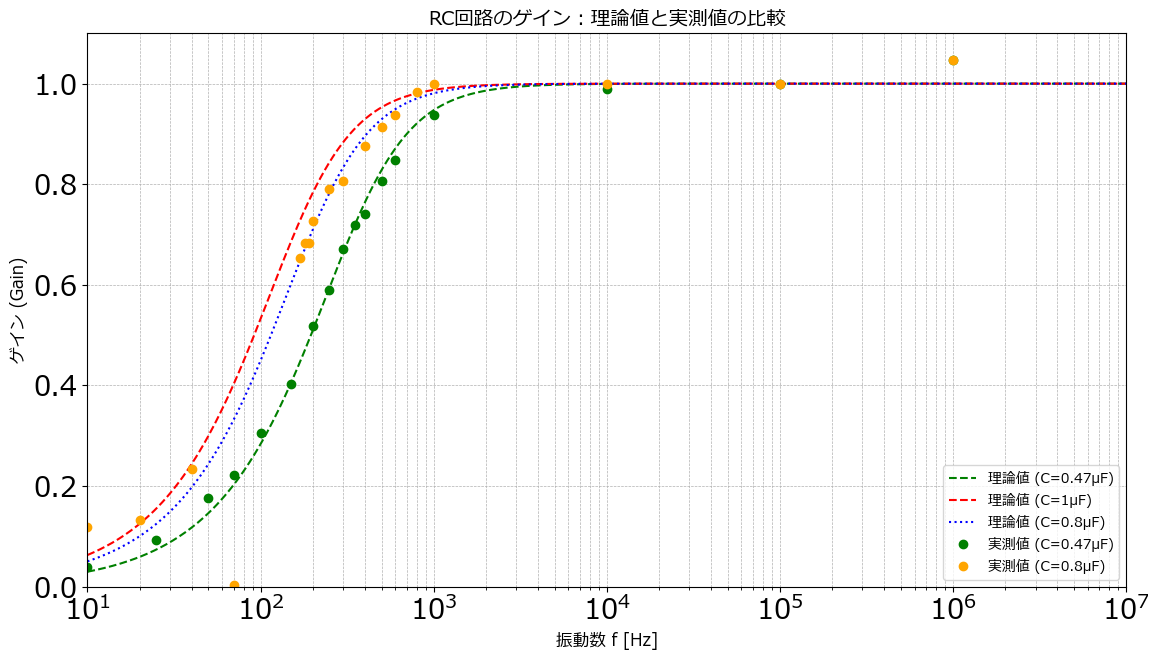

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 日本語フォントの設定 ---
# ご自身の環境に合ったフォント名またはパスを設定してください
# 例: 'Meiryo' (Windows), 'Hiragino Sans GB' (macOS), 'Noto Sans CJK JP' (Linux)
font_name = 'Meiryo' # 例: Windowsの場合

try:
    prop = fm.FontProperties(family=font_name)
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止
except Exception as e:
    print(f"Warning: Font setting failed. Error: {e}")
    print("Falling back to default font. Japanese characters might not display correctly.")
    # フォント設定が失敗した場合の代替
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False

# --- 実測値データ 1 (C=0.47µF) ---
# 振動数 [Hz] と gain のデータ (image_3f7fe2.png から手入力)
observed_frequency_0_47uF = np.array([
    10, 25, 50, 70, 100, 150, 200, 250, 300, 350, 400, 500, 600, 1000, 10000, 100000, 1000000
])
observed_gain_0_47uF = np.array([
    0.039604, 0.093333, 0.175676, 0.222222, 0.305455, 0.402985, 0.517647,
    0.590164, 0.670996, 0.718062, 0.740909, 0.806763, 0.847291, 0.937173,
    0.989418, 1, 1.047297
])

# --- 実測値データ 2 (C=0.8µF) ---
# 振動数 [Hz] と gain のデータ (image_3fe140.png から手入力)
observed_frequency_0_8uF = np.array([
    10, 20, 40, 70, 170, 180, 190, 200, 250, 300, 400, 500, 600, 800, 1000, 10000, 100000, 1000000
])
observed_gain_0_8uF = np.array([
    0.118227, 0.133333, 0.232877, 0.003731, 
    0.65368,0.682819, 0.682819, 0.727273, 0.791469, 0.806763,
    0.875, 0.913265, 0.937173, 0.983957, 1, 1, 1, 1.047297
])

# --- 理論値の計算 ---
R = 1000 # 抵抗 R [Ω]
f_theory = np.logspace(1, 7, 500) # 10 Hz 〜 10 MHz
omega_theory = 2 * np.pi * f_theory

C1 = 0.47 * 10**-6 # 0.47µF
C2 = 1.0 * 10**-6  # 1 µF
C3 = 0.8 * 10**-6  # 0.8 µF

# RCハイパス回路のゲインの理論式: Gain = R / sqrt(R^2 + X_C^2) = R / sqrt(R^2 + (1 / (omega * C))^2)
Gain_theory_C1 = R / np.sqrt(R**2 + (1 / (omega_theory * C1))**2)
Gain_theory_C2 = R / np.sqrt(R**2 + (1 / (omega_theory * C2))**2)
Gain_theory_C3 = R / np.sqrt(R**2 + (1 / (omega_theory * C3))**2)

# --- グラフ描画 ---
plt.figure(figsize=(12, 7))

# 理論値のプロット
plt.plot(f_theory, Gain_theory_C1, color='green', linestyle='--', linewidth=1.5, label='理論値 (C=0.47µF)')
plt.plot(f_theory, Gain_theory_C2, color='red', linestyle='--', linewidth=1.5, label='理論値 (C=1µF)')
plt.plot(f_theory, Gain_theory_C3, color='blue', linestyle=':', linewidth=1.5, label='理論値 (C=0.8µF)')

# 実測値のプロット (C=0.47µF)
plt.plot(observed_frequency_0_47uF, observed_gain_0_47uF, 'o', color='green', markersize=6, label='実測値 (C=0.47µF)')

# 実測値のプロット (C=0.8µF)
# 70Hzのデータ (0.003731) が非常に小さいので、プロット範囲からはみ出さないように注意
# データに異常値が含まれている可能性があるため、その点を考慮してください。
# ここでは一旦そのままプロットします。
plt.plot(observed_frequency_0_8uF, observed_gain_0_8uF, 'o', color='orange', markersize=6, label='実測値 (C=0.8µF)')


plt.xscale('log')
plt.xlabel('振動数 f [Hz]', fontsize=12)
plt.ylabel('ゲイン (Gain)', fontsize=12)
plt.title('RC回路のゲイン：理論値と実測値の比較', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=10, loc='lower right') # 凡例の位置を調整
plt.xlim(10, 10**7) # X軸の範囲を調整
plt.ylim(0, 1.1) # Y軸の範囲を調整

plt.tight_layout() # レイアウトの調整
plt.show()

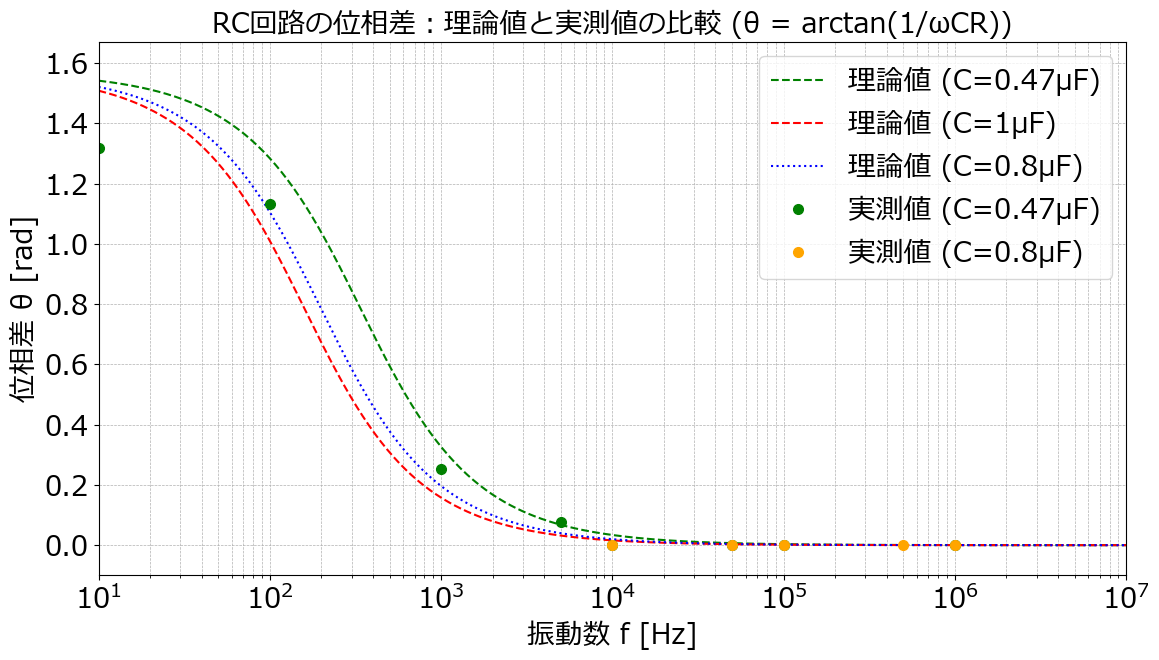

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 日本語フォントの設定 ---
# ご自身の環境に合ったフォント名またはパスを設定してください
font_name = 'Meiryo' # 例: Windowsの場合

# プロット設定
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

try:
    prop = fm.FontProperties(family=font_name)
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止
except Exception as e:
    print(f"Warning: Font setting failed. Error: {e}")
    print("Falling back to default font. Japanese characters might not display correctly.")
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False



# --- 実測値データ 2 (image_6a209e.pngから手入力) - C=0.47μF のデータとして重ねる
observed_phase_frequency_set2 = np.array([10, 100, 1000, 5000, 10000, 50000, 100000, 1000000])
observed_phase_difference_set2 = np.array([1.319469, 1.131, 0.251327, 0.07854, 0, 0, 0, 0])

# --- 実測値データ 3 (image_6a3383.pngから手入力) - C=0.8μF のデータとして重ねる
observed_phase_frequency_set3 = np.array([10000, 50000, 100000, 500000, 1000000])
observed_phase_difference_set3 = np.array([0, 0, 0, 0, 0])


# --- 理論値の計算 ---
R = 1000 # 抵抗 R [Ω]
f_theory = np.logspace(1, 7, 500) # 10 Hz 〜 10 MHz
omega_theory = 2 * np.pi * f_theory

C1 = 0.47 * 10**-6  # 0.47µF
C2 = 1.0 * 10**-6   # 1 µF
C3 = 0.8 * 10**-6   # 0.8 µF

# 位相角 θ をラジアンで計算 (ユーザー提供の式を使用: θ = arctan(1/ωCR))
theta1 = np.arctan(1 / (omega_theory * C1 * R))
theta2 = np.arctan(1 / (omega_theory * C2 * R))
theta3 = np.arctan(1 / (omega_theory * C3 * R))

# --- グラフ描画 ---
plt.figure(figsize=(12, 7))

# 理論値のプロット
plt.plot(f_theory, theta1, color='green', linestyle='--', linewidth=1.5, label='理論値 (C=0.47µF)')
plt.plot(f_theory, theta2, color='red', linestyle='--', linewidth=1.5, label='理論値 (C=1µF)')
plt.plot(f_theory, theta3, color='blue', linestyle=':', linewidth=1.5, label='理論値 (C=0.8µF)')

#

# 実測値のプロット 2 (image_6a209e.png由来、C=0.47µFと仮定)
plt.plot(observed_phase_frequency_set2, observed_phase_difference_set2, 'o', color='green', markersize=7, label='実測値 (C=0.47µF)')

# 実測値のプロット 3 (image_6a3383.png由来, C=0.8μF)
plt.plot(observed_phase_frequency_set3, observed_phase_difference_set3, 'o', color='orange', markersize=7, label='実測値 (C=0.8µF)')


plt.xscale('log')
plt.xlabel('振動数 f [Hz]', fontsize=20)
plt.ylabel('位相差 θ [rad]', fontsize=20)
plt.title('RC回路の位相差：理論値と実測値の比較 (θ = arctan(1/ωCR))', fontsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=20, loc='upper right') # 凡例の位置を調整

plt.xlim(10, 10**7) # X軸の範囲を調整
# Y軸の範囲をマイナスまで広げてゼロ値を見やすくする
plt.ylim(-0.1, np.pi / 2 + 0.1) # 下限を-0.1ラジアンに設定

plt.tight_layout() # レイアウトの調整
plt.show()

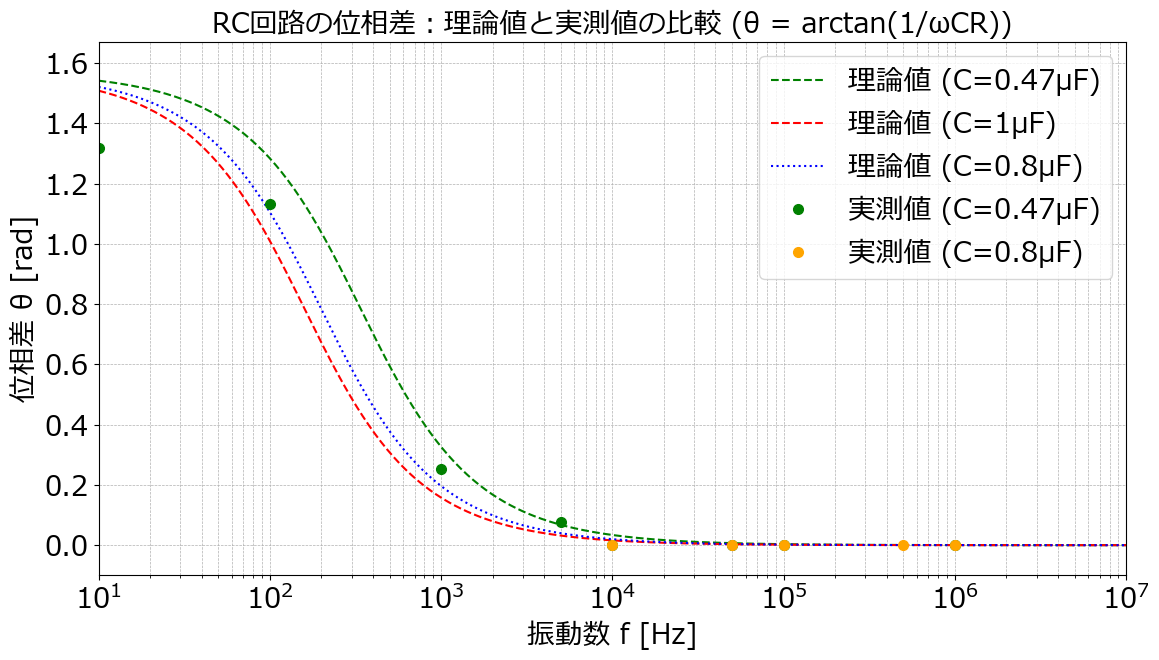

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 日本語フォントの設定 ---
# ご自身の環境に合ったフォント名またはパスを設定してください
font_name = 'Meiryo' # 例: Windowsの場合

# プロット設定
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20

try:
    prop = fm.FontProperties(family=font_name)
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化け防止
except Exception as e:
    print(f"Warning: Font setting failed. Error: {e}")
    print("Falling back to default font. Japanese characters might not display correctly.")
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False



# --- 実測値データ 2 (image_6a209e.pngから手入力) - C=0.47μF のデータとして重ねる
observed_phase_frequency_set2 = np.array([10, 100, 1000, 5000, 10000, 50000, 100000, 1000000])
observed_phase_difference_set2 = np.array([1.319469, 1.131, 0.251327, 0.07854, 0, 0, 0, 0])

# --- 実測値データ 3 (image_6a3383.pngから手入力) - C=0.8μF のデータとして重ねる
observed_phase_frequency_set3 = np.array([10000, 50000, 100000, 500000, 1000000])
observed_phase_difference_set3 = np.array([0, 0, 0, 0, 0])


# --- 理論値の計算 ---
R = 1000 # 抵抗 R [Ω]
f_theory = np.logspace(1, 7, 500) # 10 Hz 〜 10 MHz
omega_theory = 2 * np.pi * f_theory

C1 = 0.47 * 10**-6  # 0.47µF
C2 = 1.0 * 10**-6   # 1 µF
C3 = 0.8 * 10**-6   # 0.8 µF

# 位相角 θ をラジアンで計算 (ユーザー提供の式を使用: θ = arctan(1/ωCR))
theta1 = np.arctan(1 / (omega_theory * C1 * R))
theta2 = np.arctan(1 / (omega_theory * C2 * R))
theta3 = np.arctan(1 / (omega_theory * C3 * R))

# --- グラフ描画 ---
plt.figure(figsize=(12, 7))

# 理論値のプロット
plt.plot(f_theory, theta1, color='green', linestyle='--', linewidth=1.5, label='理論値 (C=0.47µF)')
plt.plot(f_theory, theta2, color='red', linestyle='--', linewidth=1.5, label='理論値 (C=1µF)')
plt.plot(f_theory, theta3, color='blue', linestyle=':', linewidth=1.5, label='理論値 (C=0.8µF)')

#

# 実測値のプロット 2 (image_6a209e.png由来、C=0.47µFと仮定)
plt.plot(observed_phase_frequency_set2, observed_phase_difference_set2, 'o', color='green', markersize=7, label='実測値 (C=0.47µF)')

# 実測値のプロット 3 (image_6a3383.png由来, C=0.8μF)
plt.plot(observed_phase_frequency_set3, observed_phase_difference_set3, 'o', color='orange', markersize=7, label='実測値 (C=0.8µF)')


plt.xscale('log')
plt.xlabel('振動数 f [Hz]', fontsize=20)
plt.ylabel('位相差 θ [rad]', fontsize=20)
plt.title('RC回路の位相差：理論値と実測値の比較 (θ = arctan(1/ωCR))', fontsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(fontsize=20, loc='upper right') # 凡例の位置を調整

plt.xlim(10, 10**7) # X軸の範囲を調整
# Y軸の範囲をマイナスまで広げてゼロ値を見やすくする
plt.ylim(-0.1, np.pi / 2 + 0.1) # 下限を-0.1ラジアンに設定

plt.tight_layout() # レイアウトの調整
plt.show()